In [1]:
library(TCGAbiolinks)
library(tidyverse)
library(maftools)
library(SummarizedExperiment)
library(ggplot2)
library(ComplexHeatmap)
library(circlize)
library(dplyr)
library(tidyr)
library(ggforce) 
library(tidyverse)
library(BSgenome.Hsapiens.UCSC.hg38)   # for seqlengths()
# For geom_sina()

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘matrixStats’


The following object is masked from ‘package:dplyr’:

    count



Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,


In [2]:
#### TCGA SV DATA DIRECTORY########
data_dir = "/tgen_labs/barthel/public_datasets/TCGA/sv/"

In [3]:
setwd(data_dir)

In [4]:
load("PCLT.SV.annotated.rda")

In [5]:
ls()

[1] "breakpoints.anno" "data_dir"

In [6]:
###LOAD SV FILE########
head(breakpoints.anno)

##LOOK THE DATA FOR UNIQUE LIBRARIES####
unique(breakpoints.anno$seqnames.x)


,seqnames.x,start.x,end.x,width.x,strand.x,sample_id,disease,library_type,Score.x,SV_type.x,⋯,geneChr.y,geneStart.y,geneEnd.y,geneLength.y,geneStrand.y,geneId.y,distanceToTSS.y,ENTREZID.y,SYMBOL.y,GENENAME.y
,<fct>,<int>,<int>,<int>,<fct>,<fct>,<chr>,<chr>,<chr>,<chr>,⋯,<int>,<int>,<int>,<int>,<int>,<chr>,<dbl>,<chr>,<chr>,<chr>
1,chr1,6997819,6998196,378,+,TCGA-BL-A0C8-01,BLCA,LPS,47.73,BND,⋯,12,133302254,133338474,36221,2,ENSG00000176915.10,-19049,23141,ANKLE2,ankyrin repeat and LEM domain containing 2
2,chr1,18387207,18387491,285,-,TCGA-BL-A0C8-01,BLCA,LPS,203.45,DUP,⋯,1,18957500,19075360,117861,1,ENSG00000009709.7,121213,5081,PAX7,paired box 7
3,chr1,19582059,19582246,188,-,TCGA-BL-A0C8-01,BLCA,LPS,142.41,DUP,⋯,1,117686209,117753556,67348,2,ENSG00000134258.12,-49395,79679,VTCN1,V-set domain containing T cell activation inhibitor 1
4,chr1,20166905,20167210,306,+,TCGA-BL-A0C8-01,BLCA,LPS,47.73,BND,⋯,1,23996784,24006749,9966,1,ENSG00000229239.2,4349,NA,NA,NA
5,chr1,23542330,23542559,230,-,TCGA-BL-A0C8-01,BLCA,LPS,91.95,BND,⋯,10,87359312,88126250,766939,2,ENSG00000182771.13,-19855,2894,GRID1,glutamate ionotropic receptor delta type subunit 1
6,chr1,42923893,42924219,327,-,TCGA-BL-A0C8-01,BLCA,LPS,81.72,DUP,⋯,1,44501798,44570647,68850,1,ENSG00000230615.2,47645,NA,NA,NA


[1] chr1  chr10 chr11 chr12 chr13 chr14 chr15 chr16 chr17 chr18 chr19 chr2 
[13] chr20 chr21 chr22 chr3  chr4  chr5  chr6  chr7  chr8  chr9  chrX  chrY 
93 Levels: chr1 chr2 chr3 chr4 chr5 chr6 chr7 chr8 chr9 chr10 chr11 ... chrUn_gl000249

In [7]:
names(breakpoints.anno)


[1] "seqnames.x"      "start.x"         "end.x"           "width.x"        
 [5] "strand.x"        "sample_id"       "disease"         "library_type"   
 [9] "Score.x"         "SV_type.x"       "Name"            "annotation.x"   
[13] "geneChr.x"       "geneStart.x"     "geneEnd.x"       "geneLength.x"   
[17] "geneStrand.x"    "geneId.x"        "distanceToTSS.x" "ENTREZID.x"     
[21] "SYMBOL.x"        "GENENAME.x"      "seqnames.y"      "start.y"        
[25] "end.y"           "width.y"         "strand.y"        "Score.y"        
[29] "SV_type.y"       "annotation.y"    "geneChr.y"       "geneStart.y"    
[33] "geneEnd.y"       "geneLength.y"    "geneStrand.y"    "geneId.y"       
[37] "distanceToTSS.y" "ENTREZID.y"      "SYMBOL.y"        "GENENAME.y"

In [8]:
#### TCGA TELOMERE DATA FILE########

load("/tgen_labs/barthel/public_datasets/TCGA/telomere_length/PCTL.telseq.anno.filtered.k7.Rdata")
head(ptel, n = 2)
nrow(ptel)

sample_id,disease,center,library_type,patient_id,pairtype,tid,nid,nlen,tlen
<chr>,<fct>,<fct>,<fct>,<fct>,<chr>,<fct>,<fct>,<dbl>,<dbl>
TCGA-02-0003-01,GBM,BI,WXS,TCGA-02-0003,TP-NB,1d46f098-bacb-4a27-845a-88632ba34c11,e663a07f-50c7-4edb-a3dc-67a831e90aca,3.9393439,3.190771
TCGA-02-0033-01,GBM,BI,WXS,TCGA-02-0033,TP-NB,57cd897f-76d1-45d2-9c29-968169127332,0c6963d6-46c0-4681-8925-f51f81cefdaa,0.6396116,1.558632


[1] 8953

In [9]:
#ptel %>% filter(tlen > 90)

In [10]:
unique(ptel$library_type)
#ptel<-  ptel %>%
#filter(library_type == "WGS")
head(ptel)
nrow(ptel)

[1] WXS WGS LPS
Levels: WGS LPS WXS

sample_id,disease,center,library_type,patient_id,pairtype,tid,nid,nlen,tlen
<chr>,<fct>,<fct>,<fct>,<fct>,<chr>,<fct>,<fct>,<dbl>,<dbl>
TCGA-02-0003-01,GBM,BI,WXS,TCGA-02-0003,TP-NB,1d46f098-bacb-4a27-845a-88632ba34c11,e663a07f-50c7-4edb-a3dc-67a831e90aca,3.9393439,3.1907709
TCGA-02-0033-01,GBM,BI,WXS,TCGA-02-0033,TP-NB,57cd897f-76d1-45d2-9c29-968169127332,0c6963d6-46c0-4681-8925-f51f81cefdaa,0.6396116,1.5586316
TCGA-02-0047-01,GBM,BI,WXS,TCGA-02-0047,TP-NB,3c04884f-a35a-4deb-95a0-b2a86cacce40,3c298a99-4aed-41fc-951f-7c70fb8aa0a0,3.8895506,2.2099445
TCGA-02-2483-01,GBM,BI,WGS,TCGA-02-2483,TP-NB,1d77eb0d-c0a9-4681-9227-b3738cbf265c,0a2475da-42bb-4adb-b86c-5492511e09f1,6.0661870,5.0797558
TCGA-02-2485-01,GBM,BI,WGS,TCGA-02-2485,TP-NB,927a31f9-3090-4f76-bbef-a06c7b079f95,515488df-7444-4249-9343-d102147ff315,6.0380911,14.6277168
TCGA-02-2486-01,GBM,BI,WXS,TCGA-02-2486,TP-NB,2d2b6ce1-5dc7-4bd2-90e7-69e12c5ebc16,c1457a37-1155-42bd-b0c8-5b86450be014,0.2920492,0.1652586


[1] 8953

In [11]:
# Select columns
ptel_subset <- ptel[, c("patient_id", "disease")]

# Save as TSV file
write.table(ptel_subset, file = "/scratch/mjehangir/tcga/ptel_sample_disease.tsv", sep = "\t", row.names = FALSE, quote = FALSE)


In [12]:
setwd('/home/mjehangir/glioma_manuscript/')

ERROR: Error in setwd("/home/mjehangir/glioma_manuscript/"): cannot change working directory


In [13]:
#ptel = ptel %>%
# filter(library_type != "WXS")

In [14]:
nrow(ptel)

[1] 8953

In [15]:
#### SUBSET THE INTERESTED COLUMNS BASED ON ANALYSIS#
tel_sample_subset <- ptel %>%
  select(sample_id, disease, nlen, tlen)
head(tel_sample_subset)
nrow(tel_sample_subset)

sample_id,disease,nlen,tlen
<chr>,<fct>,<dbl>,<dbl>
TCGA-02-0003-01,GBM,3.9393439,3.1907709
TCGA-02-0033-01,GBM,0.6396116,1.5586316
TCGA-02-0047-01,GBM,3.8895506,2.2099445
TCGA-02-2483-01,GBM,6.0661870,5.0797558
TCGA-02-2485-01,GBM,6.0380911,14.6277168
TCGA-02-2486-01,GBM,0.2920492,0.1652586


[1] 8953

In [16]:
sv_sample_subset <- breakpoints.anno %>%
  select(sample_id,start.x, end.x,seqnames.x, width.x, disease, SV_type.x)
head(sv_sample_subset)
nrow(sv_sample_subset)

,sample_id,start.x,end.x,seqnames.x,width.x,disease,SV_type.x
,<fct>,<int>,<int>,<fct>,<int>,<chr>,<chr>
1,TCGA-BL-A0C8-01,6997819,6998196,chr1,378,BLCA,BND
2,TCGA-BL-A0C8-01,18387207,18387491,chr1,285,BLCA,DUP
3,TCGA-BL-A0C8-01,19582059,19582246,chr1,188,BLCA,DUP
4,TCGA-BL-A0C8-01,20166905,20167210,chr1,306,BLCA,BND
5,TCGA-BL-A0C8-01,23542330,23542559,chr1,230,BLCA,BND
6,TCGA-BL-A0C8-01,42923893,42924219,chr1,327,BLCA,DUP


[1] 1551216

In [17]:
library(dplyr)
library(tidyr)
library(ggpubr)

In [18]:
head(tel_sample_subset)

sample_id,disease,nlen,tlen
<chr>,<fct>,<dbl>,<dbl>
TCGA-02-0003-01,GBM,3.9393439,3.1907709
TCGA-02-0033-01,GBM,0.6396116,1.5586316
TCGA-02-0047-01,GBM,3.8895506,2.2099445
TCGA-02-2483-01,GBM,6.0661870,5.0797558
TCGA-02-2485-01,GBM,6.0380911,14.6277168
TCGA-02-2486-01,GBM,0.2920492,0.1652586


In [19]:
options(repr.plot.width = 5, repr.plot.height = 4, repr.plot.res = 200)

In [20]:


# Filter for the diseases of interest (GBM and LGG)
tel_data <- tel_sample_subset %>%
  filter(disease %in% c("GBM", "LGG"))

# Transform the data from wide to long format, keeping the sample_id if needed later.
tel_data_long <- tel_data %>%
  pivot_longer(
    cols = c(nlen, tlen),
    names_to = "telomere_type",
    values_to = "length"
  )


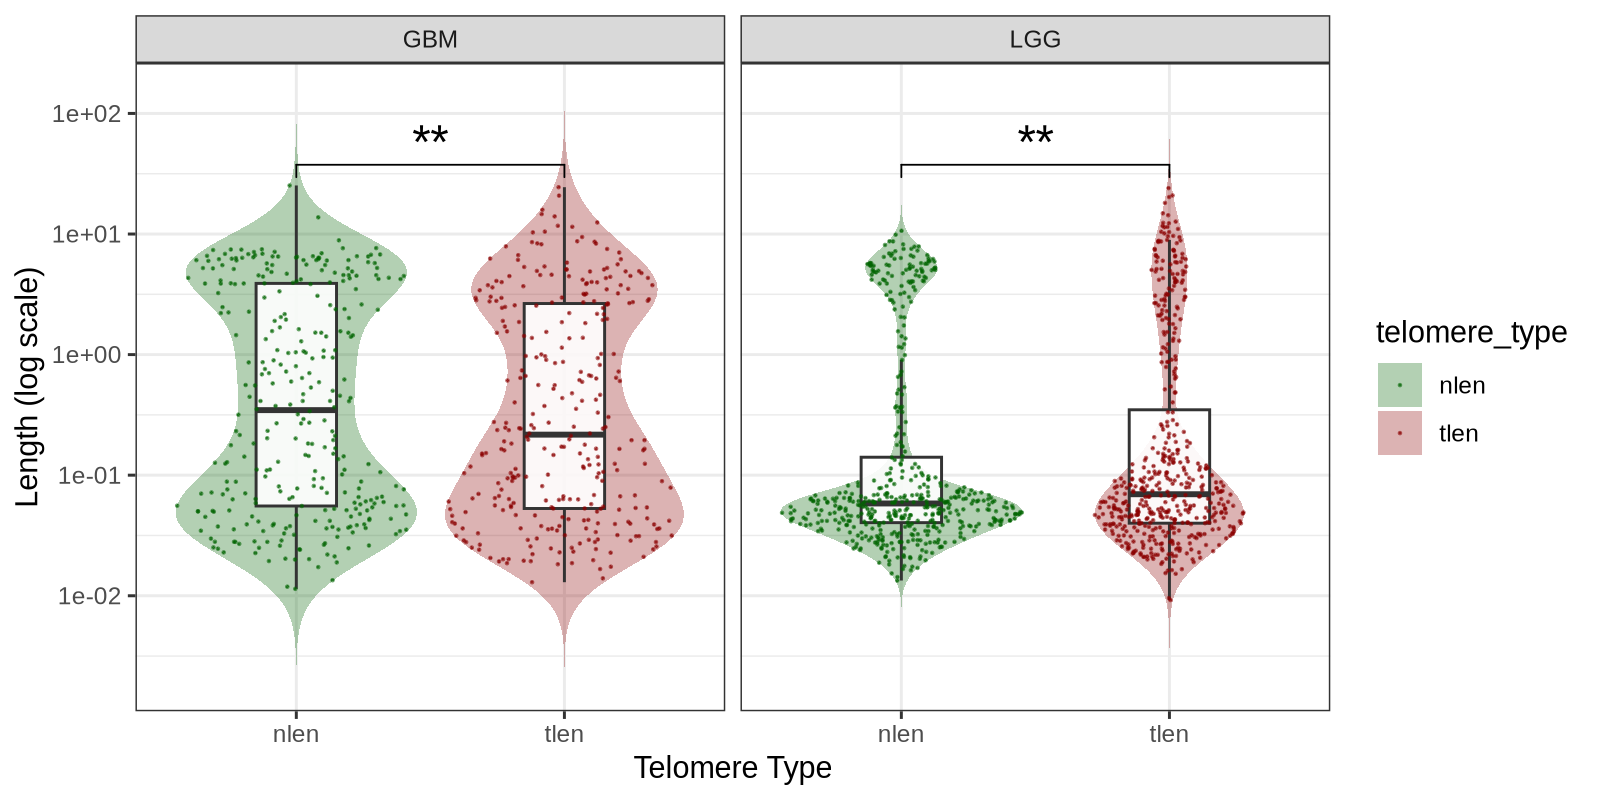

In [21]:
#For total dataplot

options(repr.plot.width = 8, repr.plot.height = 4, repr.plot.res = 200)
# Create the sinaplot violin plot with an internal white boxplot
library(ggplot2)
library(ggforce)   # For geom_sina()
library(ggpubr)    # For stat_compare_means()

#pdf(file = "GBM_telomere_lenght_normal_vs_short_all_libraries.pdf", width = 8, heigh = 4)
ggplot(tel_data_long, aes(x = telomere_type, y = length, fill = telomere_type)) +
  # Violin plot to show density distribution
  geom_violin(trim = FALSE, alpha = 0.3, color = NA) +
  # White boxplot overlay for median and IQR
  geom_boxplot(width = 0.3, fill = "white", outlier.shape = NA, alpha = 0.9) +
  # Sinaplot for showing individual data points, points colored by telomere_type
  geom_sina(aes(color = telomere_type), size = 0.1, alpha = 0.6) +
  # Facet the plot by disease type (e.g., GBM and LGG)
  facet_wrap(~ disease) +
  # Log-transform the y-axis to better display high variation in values
  scale_y_log10() +
  # Manually set the colors for nlen and tlen
  scale_fill_manual(values = c("nlen" = "darkgreen", "tlen" = "darkred")) +
  scale_color_manual(values = c("nlen" = "darkgreen", "tlen" = "darkred")) +
  # Add axis labels and use a clean, minimal theme
  labs(x = "Telomere Type", y = "Length (log scale)") +
  theme_bw() +
  # Add Wilcoxon paired test significance; comparison list explicitly compares nlen vs. tlen
  stat_compare_means(comparisons = list(c("nlen", "tlen")), 
                     method = "wilcox.test", paired = TRUE, label = "p.signif", size = 6)
#dev.off()

In [22]:
# Filter for the diseases of interest (GBM and LGG)
tel_data <- tel_sample_subset %>%
  filter(!disease %in% c("GBM", "LGG"))

# Transform the data from wide to long format, keeping the sample_id if needed later.
tel_data_long <- tel_data %>%
  pivot_longer(
    cols = c(nlen, tlen),
    names_to = "telomere_type",
    values_to = "length"
  )

In [23]:
setwd('/home/mjehangir/glioma_manuscript/')

ERROR: Error in setwd("/home/mjehangir/glioma_manuscript/"): cannot change working directory


In [24]:
unique(sv_sample_subset$disease)

[1] "BLCA" "BRCA" "CESC" "ESCA" "HNSC" "LGG"  "LUAD" "PRAD" "SKCM" "STAD"
[11] "THCA" "UCEC" "UVM"  "COAD" "DLBC" "GBM"  "KICH" "KIRC" "KIRP" "LAML"
[21] "LIHC" "LUSC" "OV"   "READ" "SARC"

In [25]:
nrow(sv_sample_subset)

[1] 1551216

In [26]:
head(tel_sample_subset)

sample_id,disease,nlen,tlen
<chr>,<fct>,<dbl>,<dbl>
TCGA-02-0003-01,GBM,3.9393439,3.1907709
TCGA-02-0033-01,GBM,0.6396116,1.5586316
TCGA-02-0047-01,GBM,3.8895506,2.2099445
TCGA-02-2483-01,GBM,6.0661870,5.0797558
TCGA-02-2485-01,GBM,6.0380911,14.6277168
TCGA-02-2486-01,GBM,0.2920492,0.1652586


In [27]:
head(sv_sample_subset)

,sample_id,start.x,end.x,seqnames.x,width.x,disease,SV_type.x
,<fct>,<int>,<int>,<fct>,<int>,<chr>,<chr>
1,TCGA-BL-A0C8-01,6997819,6998196,chr1,378,BLCA,BND
2,TCGA-BL-A0C8-01,18387207,18387491,chr1,285,BLCA,DUP
3,TCGA-BL-A0C8-01,19582059,19582246,chr1,188,BLCA,DUP
4,TCGA-BL-A0C8-01,20166905,20167210,chr1,306,BLCA,BND
5,TCGA-BL-A0C8-01,23542330,23542559,chr1,230,BLCA,BND
6,TCGA-BL-A0C8-01,42923893,42924219,chr1,327,BLCA,DUP


In [28]:
library(dplyr)

# Assuming your merged data frame is named merged_df

# Extract unique sample_id and disease
unique_samples <- sv_sample_subset %>%
  select(sample_id, disease) %>%
  distinct()

# Save to CSV file
write.csv(unique_samples, "/scratch/mjehangir/tcga/IDs_sample_disease.csv", row.names = FALSE)


In [29]:
# Merge datasets on sample_id
merged_data <- tel_sample_subset %>%
  inner_join(sv_sample_subset, by = c("sample_id", "disease"))

# Calculate telomere length difference (normal - tumor)
merged_data <- merged_data %>%
  mutate(telomere_diff = nlen - tlen)
head(merged_data)

sample_id,disease,nlen,tlen,start.x,end.x,seqnames.x,width.x,SV_type.x,telomere_diff
<chr>,<chr>,<dbl>,<dbl>,<int>,<int>,<fct>,<int>,<chr>,<dbl>
TCGA-02-2483-01,GBM,6.066187,5.079756,9688116,9688117,chr1,2,BND,0.9864312
TCGA-02-2483-01,GBM,6.066187,5.079756,9881194,9881195,chr1,2,BND,0.9864312
TCGA-02-2483-01,GBM,6.066187,5.079756,11433931,11434376,chr1,446,BND,0.9864312
TCGA-02-2483-01,GBM,6.066187,5.079756,25047809,25047819,chr1,11,BND,0.9864312
TCGA-02-2483-01,GBM,6.066187,5.079756,30196715,30196735,chr1,21,BND,0.9864312
TCGA-02-2483-01,GBM,6.066187,5.079756,48608805,48608824,chr1,20,DUP,0.9864312


In [30]:
merged_data %>%
  group_by(SV_type.x) %>%
  summarize(mean_diff = mean(telomere_diff, na.rm = TRUE)) %>% head()

SV_type.x,mean_diff
<chr>,<dbl>
BND,0.4235677
DEL,1.1730980
DUP,0.6270232
INV,0.6092070


In [31]:
plot_data = merged_data %>%
  group_by(SV_type.x, disease) %>%
  summarize(mean_diff = mean(telomere_diff, na.rm = TRUE))

`summarise()` has grouped output by 'SV_type.x'. You can override using the
`.groups` argument.


In [32]:
#plot_data = plot_data %>% filter(mean_diff > 0)

In [33]:
head(merged_data)

sample_id,disease,nlen,tlen,start.x,end.x,seqnames.x,width.x,SV_type.x,telomere_diff
<chr>,<chr>,<dbl>,<dbl>,<int>,<int>,<fct>,<int>,<chr>,<dbl>
TCGA-02-2483-01,GBM,6.066187,5.079756,9688116,9688117,chr1,2,BND,0.9864312
TCGA-02-2483-01,GBM,6.066187,5.079756,9881194,9881195,chr1,2,BND,0.9864312
TCGA-02-2483-01,GBM,6.066187,5.079756,11433931,11434376,chr1,446,BND,0.9864312
TCGA-02-2483-01,GBM,6.066187,5.079756,25047809,25047819,chr1,11,BND,0.9864312
TCGA-02-2483-01,GBM,6.066187,5.079756,30196715,30196735,chr1,21,BND,0.9864312
TCGA-02-2483-01,GBM,6.066187,5.079756,48608805,48608824,chr1,20,DUP,0.9864312


In [34]:
plot_data1 = merged_data %>%
  group_by(sample_id, SV_type.x, disease, nlen,	tlen) %>%
  summarize()

`summarise()` has grouped output by 'sample_id', 'SV_type.x', 'disease',
'nlen'. You can override using the `.groups` argument.


In [35]:
head(plot_data1)

sample_id,SV_type.x,disease,nlen,tlen
<chr>,<chr>,<chr>,<dbl>,<dbl>
TCGA-02-2483-01,BND,GBM,6.066187,5.079756
TCGA-02-2483-01,DEL,GBM,6.066187,5.079756
TCGA-02-2483-01,DUP,GBM,6.066187,5.079756
TCGA-02-2483-01,INV,GBM,6.066187,5.079756
TCGA-02-2485-01,BND,GBM,6.038091,14.627717
TCGA-02-2485-01,DEL,GBM,6.038091,14.627717


In [36]:
nrow(plot_data1)

[1] 6527

In [37]:
head(merged_data)

sample_id,disease,nlen,tlen,start.x,end.x,seqnames.x,width.x,SV_type.x,telomere_diff
<chr>,<chr>,<dbl>,<dbl>,<int>,<int>,<fct>,<int>,<chr>,<dbl>
TCGA-02-2483-01,GBM,6.066187,5.079756,9688116,9688117,chr1,2,BND,0.9864312
TCGA-02-2483-01,GBM,6.066187,5.079756,9881194,9881195,chr1,2,BND,0.9864312
TCGA-02-2483-01,GBM,6.066187,5.079756,11433931,11434376,chr1,446,BND,0.9864312
TCGA-02-2483-01,GBM,6.066187,5.079756,25047809,25047819,chr1,11,BND,0.9864312
TCGA-02-2483-01,GBM,6.066187,5.079756,30196715,30196735,chr1,21,BND,0.9864312
TCGA-02-2483-01,GBM,6.066187,5.079756,48608805,48608824,chr1,20,DUP,0.9864312


In [38]:
library(dplyr)

merged_data_sv_density <- merged_data %>%
  group_by(sample_id, SV_type.x) %>%
  mutate(total_SV_size = sum(width.x),
         total_SV_count = n(),
         SV_density = (total_SV_size/ 3.1e9),
         SV_proportion = (total_SV_count/ 3.1e9)) %>%

  ungroup() %>%
  select(sample_id, nlen, tlen, disease, total_SV_size, total_SV_count, SV_density, SV_proportion, SV_type.x, telomere_diff)

In [39]:
#filter the GBM and LGG from the dataset because we will evaluuate seperatly
merged_data_sv_density <- merged_data_sv_density %>%
  filter(!disease %in% c("LGG", "GBM"))
head(merged_data_sv_density)


sample_id,nlen,tlen,disease,total_SV_size,total_SV_count,SV_density,SV_proportion,SV_type.x,telomere_diff
<chr>,<dbl>,<dbl>,<chr>,<int>,<int>,<dbl>,<dbl>,<chr>,<dbl>
TCGA-04-1331-01,5.387169,19.71781,OV,16774,131,5.410968e-06,4.225806e-08,BND,-14.33064
TCGA-04-1331-01,5.387169,19.71781,OV,10433,164,3.365484e-06,5.290323e-08,DEL,-14.33064
TCGA-04-1331-01,5.387169,19.71781,OV,10433,164,3.365484e-06,5.290323e-08,DEL,-14.33064
TCGA-04-1331-01,5.387169,19.71781,OV,16774,131,5.410968e-06,4.225806e-08,BND,-14.33064
TCGA-04-1331-01,5.387169,19.71781,OV,16774,131,5.410968e-06,4.225806e-08,BND,-14.33064
TCGA-04-1331-01,5.387169,19.71781,OV,16774,131,5.410968e-06,4.225806e-08,BND,-14.33064


In [40]:
merged_data_sv_density = unique(merged_data_sv_density)

In [41]:
nrow(merged_data_sv_density)

[1] 6061

In [42]:
merged_data_sv_density = merged_data_sv_density %>% filter(telomere_diff > 0)

In [44]:
####################GLIOMA suntypes Analysis##############

In [45]:
glioma_idh_status = read.csv(file = "/home/mjehangir/glioma_manuscript/tcga_analysis/glioma_status.txt", header = TRUE, sep = "\t")
head(glioma_idh_status)

,WT,Non.codel,codel
,<chr>,<chr>,<chr>
1,TCGA-CS-4941,TCGA-CS-4938,TCGA-CS-5390
2,TCGA-CS-5395,TCGA-CS-4942,TCGA-CS-5396
3,TCGA-CS-5397,TCGA-CS-4943,TCGA-CS-6668
4,TCGA-CS-6186,TCGA-CS-4944,TCGA-CS-6670
5,TCGA-CS-6188,TCGA-CS-5393,TCGA-DB-5274
6,TCGA-CS-6669,TCGA-CS-5394,TCGA-DB-5278


In [46]:
df_mapping <- glioma_idh_status %>%
  pivot_longer(cols = everything(), names_to = "category", values_to = "patient_id")
head(df_mapping)

category,patient_id
<chr>,<chr>
WT,TCGA-CS-4941
Non.codel,TCGA-CS-4938
codel,TCGA-CS-5390
WT,TCGA-CS-5395
Non.codel,TCGA-CS-4942
codel,TCGA-CS-5396


In [47]:
# Filter for the diseases of interest (GBM and LGG)
tel_data_lgg_gbm <- ptel %>%
  filter(disease %in% c("LGG", "GBM"))
#tel_data_lgg_gbm <- ptel %>%
 # filter(disease %in% c("LGG", "GBM"), library_type != "WXS")

head(tel_data_lgg_gbm, n = 2)
nrow(tel_data_lgg_gbm)

sample_id,disease,center,library_type,patient_id,pairtype,tid,nid,nlen,tlen
<chr>,<fct>,<fct>,<fct>,<fct>,<chr>,<fct>,<fct>,<dbl>,<dbl>
TCGA-02-0003-01,GBM,BI,WXS,TCGA-02-0003,TP-NB,1d46f098-bacb-4a27-845a-88632ba34c11,e663a07f-50c7-4edb-a3dc-67a831e90aca,3.9393439,3.190771
TCGA-02-0033-01,GBM,BI,WXS,TCGA-02-0033,TP-NB,57cd897f-76d1-45d2-9c29-968169127332,0c6963d6-46c0-4681-8925-f51f81cefdaa,0.6396116,1.558632


[1] 822

In [48]:
# Filter for the diseases of interest (GBM and LGG)

sv_data_lgg_gbm <- breakpoints.anno %>%
  filter(disease %in% c("LGG", "GBM"))
head(sv_data_lgg_gbm, n= 2)
nrow(sv_data_lgg_gbm)

,seqnames.x,start.x,end.x,width.x,strand.x,sample_id,disease,library_type,Score.x,SV_type.x,⋯,geneChr.y,geneStart.y,geneEnd.y,geneLength.y,geneStrand.y,geneId.y,distanceToTSS.y,ENTREZID.y,SYMBOL.y,GENENAME.y
,<fct>,<int>,<int>,<int>,<fct>,<fct>,<chr>,<chr>,<chr>,<chr>,⋯,<int>,<int>,<int>,<int>,<int>,<chr>,<dbl>,<chr>,<chr>,<chr>
1,chr1,66024127,66024568,442,+,TCGA-CS-4938-01,LGG,LPS,107.54,DEL,⋯,1,65886248,66107242,220995,1,ENSG00000116678.14,143739,3953,LEPR,leptin receptor
2,chr1,144896255,144896495,241,+,TCGA-CS-4938-01,LGG,LPS,148.33,DEL,⋯,1,144836157,145076186,240030,2,ENSG00000178104.15,-169368,9659,PDE4DIP,phosphodiesterase 4D interacting protein


[1] 36468

In [49]:
# Merge datasets on sample_id
merged_data_lgg_gbm <-  tel_data_lgg_gbm %>%
  inner_join(sv_data_lgg_gbm, by = c("sample_id"))

# Calculate telomere length difference (normal - tumor)
merged_data_lgg_gbm <- merged_data_lgg_gbm %>%
  mutate(telomere_diff = nlen - tlen)

head(merged_data_lgg_gbm, n = 3)
nrow(merged_data_lgg_gbm)

sample_id,disease.x,center,library_type.x,patient_id,pairtype,tid,nid,nlen,tlen,⋯,geneStart.y,geneEnd.y,geneLength.y,geneStrand.y,geneId.y,distanceToTSS.y,ENTREZID.y,SYMBOL.y,GENENAME.y,telomere_diff
<chr>,<fct>,<fct>,<fct>,<fct>,<chr>,<fct>,<fct>,<dbl>,<dbl>,⋯,<int>,<int>,<int>,<int>,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>
TCGA-02-2483-01,GBM,BI,WGS,TCGA-02-2483,TP-NB,1d77eb0d-c0a9-4681-9227-b3738cbf265c,0a2475da-42bb-4adb-b86c-5492511e09f1,6.066187,5.079756,⋯,74127098,74385899,258802,2,ENSG00000107745.12,-208001,10367,MICU1,mitochondrial calcium uptake 1,0.9864312
TCGA-02-2483-01,GBM,BI,WGS,TCGA-02-2483,TP-NB,1d77eb0d-c0a9-4681-9227-b3738cbf265c,0a2475da-42bb-4adb-b86c-5492511e09f1,6.066187,5.079756,⋯,70587298,70655188,67891,1,ENSG00000165730.10,15147,219736,STOX1,storkhead box 1,0.9864312
TCGA-02-2483-01,GBM,BI,WGS,TCGA-02-2483,TP-NB,1d77eb0d-c0a9-4681-9227-b3738cbf265c,0a2475da-42bb-4adb-b86c-5492511e09f1,6.066187,5.079756,⋯,26677490,26686889,9400,1,ENSG00000222004.3,1541,NA,NA,NA,0.9864312


[1] 25764

In [50]:
library(dplyr)

# Unique IDs in each dataset
ids_tel <- tel_data_lgg_gbm %>% distinct(sample_id)
ids_sv <- sv_data_lgg_gbm %>% distinct(sample_id)

# Matched IDs
matched_ids <- intersect(ids_tel$sample_id, ids_sv$sample_id)

# Unmatched IDs
unmatched_ids <- union(ids_tel$sample_id, ids_sv$sample_id) %>%
  setdiff(matched_ids)

# Report counts
cat("Matched sample_ids:", length(matched_ids), "\n")
cat("Unmatched sample_ids (present in only one dataset):", length(unmatched_ids), "\n")


Matched sample_ids: 139 
Unmatched sample_ids (present in only one dataset): 708 


In [51]:
sv_tel_summary <- merged_data_lgg_gbm %>%
  group_by(patient_id, SV_type.x) %>%
  summarise(
    SV_count = n(),
    Total_width = sum(width.x, na.rm = TRUE),
    telomere_diff = dplyr::first(telomere_diff),
    nlen = dplyr::first(nlen),
    tlen = dplyr::first(tlen),
    .groups = "drop"
  )
head(sv_tel_summary, n = 5)
nrow(sv_tel_summary)


patient_id,SV_type.x,SV_count,Total_width,telomere_diff,nlen,tlen
<fct>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>
TCGA-02-2483,BND,115,8429,0.9864312,6.066187,5.079756
TCGA-02-2483,DEL,24,1877,0.9864312,6.066187,5.079756
TCGA-02-2483,DUP,34,4168,0.9864312,6.066187,5.079756
TCGA-02-2483,INV,3,29,0.9864312,6.066187,5.079756
TCGA-02-2485,BND,81,10069,-8.5896257,6.038091,14.627717


[1] 466

In [55]:
# Define genome size in Mb
#genome_size_mb <- 3100

# Add SV_density and Proportion
sv_tel_summary <- sv_tel_summary %>%
  mutate(
    #Total_width_mb = Total_width / 1e6,
    #SV_density = Total_width_mb / genome_size_mb,
SV_density = (Total_width / 3.1e9),
      # size-based density
    SV_proportion = (SV_count / 3.1e9)                  # count-based proportion
  )
head(sv_tel_summary, n = 3)
nrow(sv_tel_summary)

patient_id,SV_type.x,SV_count,Total_width,telomere_diff,nlen,tlen,SV_density,SV_proportion
<fct>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
TCGA-02-2483,BND,115,8429,0.9864312,6.066187,5.079756,2.719032e-06,3.709677e-08
TCGA-02-2483,DEL,24,1877,0.9864312,6.066187,5.079756,6.054839e-07,7.741935e-09
TCGA-02-2483,DUP,34,4168,0.9864312,6.066187,5.079756,1.344516e-06,1.096774e-08


[1] 466

In [56]:
sv_tel_summary <- sv_tel_summary %>%
  inner_join(df_mapping, by = "patient_id")
head(sv_tel_summary)
nrow(sv_tel_summary)

patient_id,SV_type.x,SV_count,Total_width,telomere_diff,nlen,tlen,SV_density,SV_proportion,category
<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
TCGA-02-2483,BND,115,8429,0.9864312,6.066187,5.079756,2.719032e-06,3.709677e-08,Non.codel
TCGA-02-2483,DEL,24,1877,0.9864312,6.066187,5.079756,6.054839e-07,7.741935e-09,Non.codel
TCGA-02-2483,DUP,34,4168,0.9864312,6.066187,5.079756,1.344516e-06,1.096774e-08,Non.codel
TCGA-02-2483,INV,3,29,0.9864312,6.066187,5.079756,9.354839e-09,9.677419e-10,Non.codel
TCGA-02-2485,BND,81,10069,-8.5896257,6.038091,14.627717,3.248065e-06,2.612903e-08,WT
TCGA-02-2485,DEL,27,4874,-8.5896257,6.038091,14.627717,1.572258e-06,8.709677e-09,WT


[1] 446

In [57]:
sv_tel_summary <- sv_tel_summary[sv_tel_summary$SV_type.x != "BND", ]

In [58]:
################change the type here for plot###########################

ids <- sv_tel_summary %>%
  filter(category == "Non.codel") %>%
  pull(patient_id) %>%
  unique()


In [59]:
merged_subset_idh <- merged_data_lgg_gbm %>%
  filter(patient_id %in% ids)
head(merged_subset_idh)
nrow(merged_subset_idh)

sample_id,disease.x,center,library_type.x,patient_id,pairtype,tid,nid,nlen,tlen,⋯,geneStart.y,geneEnd.y,geneLength.y,geneStrand.y,geneId.y,distanceToTSS.y,ENTREZID.y,SYMBOL.y,GENENAME.y,telomere_diff
<chr>,<fct>,<fct>,<fct>,<fct>,<chr>,<fct>,<fct>,<dbl>,<dbl>,⋯,<int>,<int>,<int>,<int>,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>
TCGA-02-2483-01,GBM,BI,WGS,TCGA-02-2483,TP-NB,1d77eb0d-c0a9-4681-9227-b3738cbf265c,0a2475da-42bb-4adb-b86c-5492511e09f1,6.066187,5.079756,⋯,74127098,74385899,258802,2,ENSG00000107745.12,-208001,10367,MICU1,mitochondrial calcium uptake 1,0.9864312
TCGA-02-2483-01,GBM,BI,WGS,TCGA-02-2483,TP-NB,1d77eb0d-c0a9-4681-9227-b3738cbf265c,0a2475da-42bb-4adb-b86c-5492511e09f1,6.066187,5.079756,⋯,70587298,70655188,67891,1,ENSG00000165730.10,15147,219736,STOX1,storkhead box 1,0.9864312
TCGA-02-2483-01,GBM,BI,WGS,TCGA-02-2483,TP-NB,1d77eb0d-c0a9-4681-9227-b3738cbf265c,0a2475da-42bb-4adb-b86c-5492511e09f1,6.066187,5.079756,⋯,26677490,26686889,9400,1,ENSG00000222004.3,1541,NA,NA,NA,0.9864312
TCGA-02-2483-01,GBM,BI,WGS,TCGA-02-2483,TP-NB,1d77eb0d-c0a9-4681-9227-b3738cbf265c,0a2475da-42bb-4adb-b86c-5492511e09f1,6.066187,5.079756,⋯,2822011,2847392,25382,2,ENSG00000006756.11,-11609,414,ARSD,arylsulfatase D,0.9864312
TCGA-02-2483-01,GBM,BI,WGS,TCGA-02-2483,TP-NB,1d77eb0d-c0a9-4681-9227-b3738cbf265c,0a2475da-42bb-4adb-b86c-5492511e09f1,6.066187,5.079756,⋯,134735494,134955295,219802,2,ENSG00000160563.9,-115572,9442,MED27,mediator complex subunit 27,0.9864312
TCGA-02-2483-01,GBM,BI,WGS,TCGA-02-2483,TP-NB,1d77eb0d-c0a9-4681-9227-b3738cbf265c,0a2475da-42bb-4adb-b86c-5492511e09f1,6.066187,5.079756,⋯,170501270,170522587,21318,1,ENSG00000120370.8,15683,92344,GORAB,"golgin, RAB6-interacting",0.9864312


[1] 4738

In [60]:
# Step 1: Extract unique sample IDs from TCGA data by codel, noncodel and WT
ids <- unique(merged_subset_idh$sample_id)

# Step 2: Filter `sv_sample_subset` for those IDs
sv_subtype <- sv_sample_subset %>%
  dplyr::filter(sample_id %in% ids)

# Step 3 (optional): Inspect the filtered SVs
head(sv_subtype)
nrow(sv_subtype)
#write.table(head(sv_noncodel), file = "/scratch/mjehangir/TCGA_noncodel_SV.txt", sep = "\t", row.names = FALSE, quote = FALSE)

,sample_id,start.x,end.x,seqnames.x,width.x,disease,SV_type.x
,<fct>,<int>,<int>,<fct>,<int>,<chr>,<chr>
1,TCGA-CS-4938-01,66024127,66024568,chr1,442,LGG,DEL
2,TCGA-CS-4938-01,144896255,144896495,chr1,241,LGG,DEL
3,TCGA-CS-4938-01,67306886,67307152,chr10,267,LGG,DEL
4,TCGA-CS-4938-01,70998108,70998554,chr10,447,LGG,DEL
5,TCGA-CS-4938-01,97207041,97207421,chr10,381,LGG,DEL
6,TCGA-CS-4938-01,29844366,29844588,chr12,223,LGG,DEL


[1] 4738

In [61]:
unique_sv_types <- sv_subtype %>%
  distinct(SV_type.x)

print(unique_sv_types)

  SV_type.x
1       DEL
2       INV
3       DUP
4       BND


In [62]:
head(sv_subtype)

,sample_id,start.x,end.x,seqnames.x,width.x,disease,SV_type.x
,<fct>,<int>,<int>,<fct>,<int>,<chr>,<chr>
1,TCGA-CS-4938-01,66024127,66024568,chr1,442,LGG,DEL
2,TCGA-CS-4938-01,144896255,144896495,chr1,241,LGG,DEL
3,TCGA-CS-4938-01,67306886,67307152,chr10,267,LGG,DEL
4,TCGA-CS-4938-01,70998108,70998554,chr10,447,LGG,DEL
5,TCGA-CS-4938-01,97207041,97207421,chr10,381,LGG,DEL
6,TCGA-CS-4938-01,29844366,29844588,chr12,223,LGG,DEL


In [63]:
sv_subtype %>% filter(SV_type.x == "BND") %>% nrow()

[1] 2670

In [64]:
library(rtracklayer)                       

In [65]:
library(GenomeInfoDb)

In [66]:
# CRAN / Bioc packages (install if needed):
# install.packages(c("tidyverse","BSgenome.Hsapiens.UCSC.hg38"))
# BiocManager::install("BSgenome.Hsapiens.UCSC.hg38")


# ——————————————————————————————————————————————
# 1. Download hg38 cytoband directly from UCSC
# ——————————————————————————————————————————————
cyto_url <- "http://hgdownload.cse.ucsc.edu/goldenPath/hg38/database/cytoBand.txt.gz"
cyto <- read_tsv(cyto_url,
                 col_names = c("seqnames","start","end","band","stain"),
                 show_col_types = FALSE)

# ——————————————————————————————————————————————
# 2. Compute centromere bounds per chromosome
# ——————————————————————————————————————————————
centromeres <- cyto %>%
  filter(stain == "acen") %>%               # “acen” marks centric bands
  group_by(seqnames) %>%
  summarize(
    cen_start = min(start),
    cen_end   = max(end),
    .groups   = "drop"
  )

# ——————————————————————————————————————————————
# 3. Define 1 Mb telomere windows at each end of chr1–22
# ——————————————————————————————————————————————
chrom_lengths <- seqlengths(Hsapiens)[paste0("chr", 1:22)]
tel_len <- 1e6
telomeres <- tibble(
  seqnames = names(chrom_lengths),
  chr_len   = as.numeric(chrom_lengths)
) %>%
  mutate(
    tel_p_start = 0,
    tel_p_end   = pmin(tel_len, chr_len),
    tel_q_start = pmax(0, chr_len - tel_len),
    tel_q_end   = chr_len
  )

# ——————————————————————————————————————————————
# 4. Scale your TCGA SV midpoints to [0,1]
# ——————————————————————————————————————————————
sv_scaled_subtype <- sv_subtype %>%
  mutate(midpoint = (start.x + end.x) / 2) %>%
  left_join(
    tibble(seqnames = names(chrom_lengths), chr_length = as.numeric(chrom_lengths)),
    by = c("seqnames.x" = "seqnames")
  ) %>%
  mutate(scaled_pos = midpoint / chr_length) %>%
  filter(!is.na(scaled_pos))

# ——————————————————————————————————————————————
# 5. Build unified “shade_regions” in normalized coords
# ——————————————————————————————————————————————
shade_cent <- centromeres %>%
  left_join(
    tibble(seqnames = names(chrom_lengths), chr_length = as.numeric(chrom_lengths)),
    by = "seqnames"
  ) %>%
  transmute(
    seqnames,
    type = "centromere",
    xmin = cen_start / chr_length,
    xmax = cen_end   / chr_length
  )

shade_tel_p <- telomeres %>%
  transmute(
    seqnames,
    type = "tel_p",
    xmin = tel_p_start / chr_len,
    xmax = tel_p_end   / chr_len
  )

shade_tel_q <- telomeres %>%
  transmute(
    seqnames,
    type = "tel_q",
    xmin = tel_q_start / chr_len,
    xmax = tel_q_end   / chr_len
  )

shade_regions <- bind_rows(shade_cent, shade_tel_p, shade_tel_q)

In [67]:
sv_scaled_subtype <- sv_scaled_subtype[sv_scaled_subtype$SV_type.x != "BND", ]


Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_rect()`).”


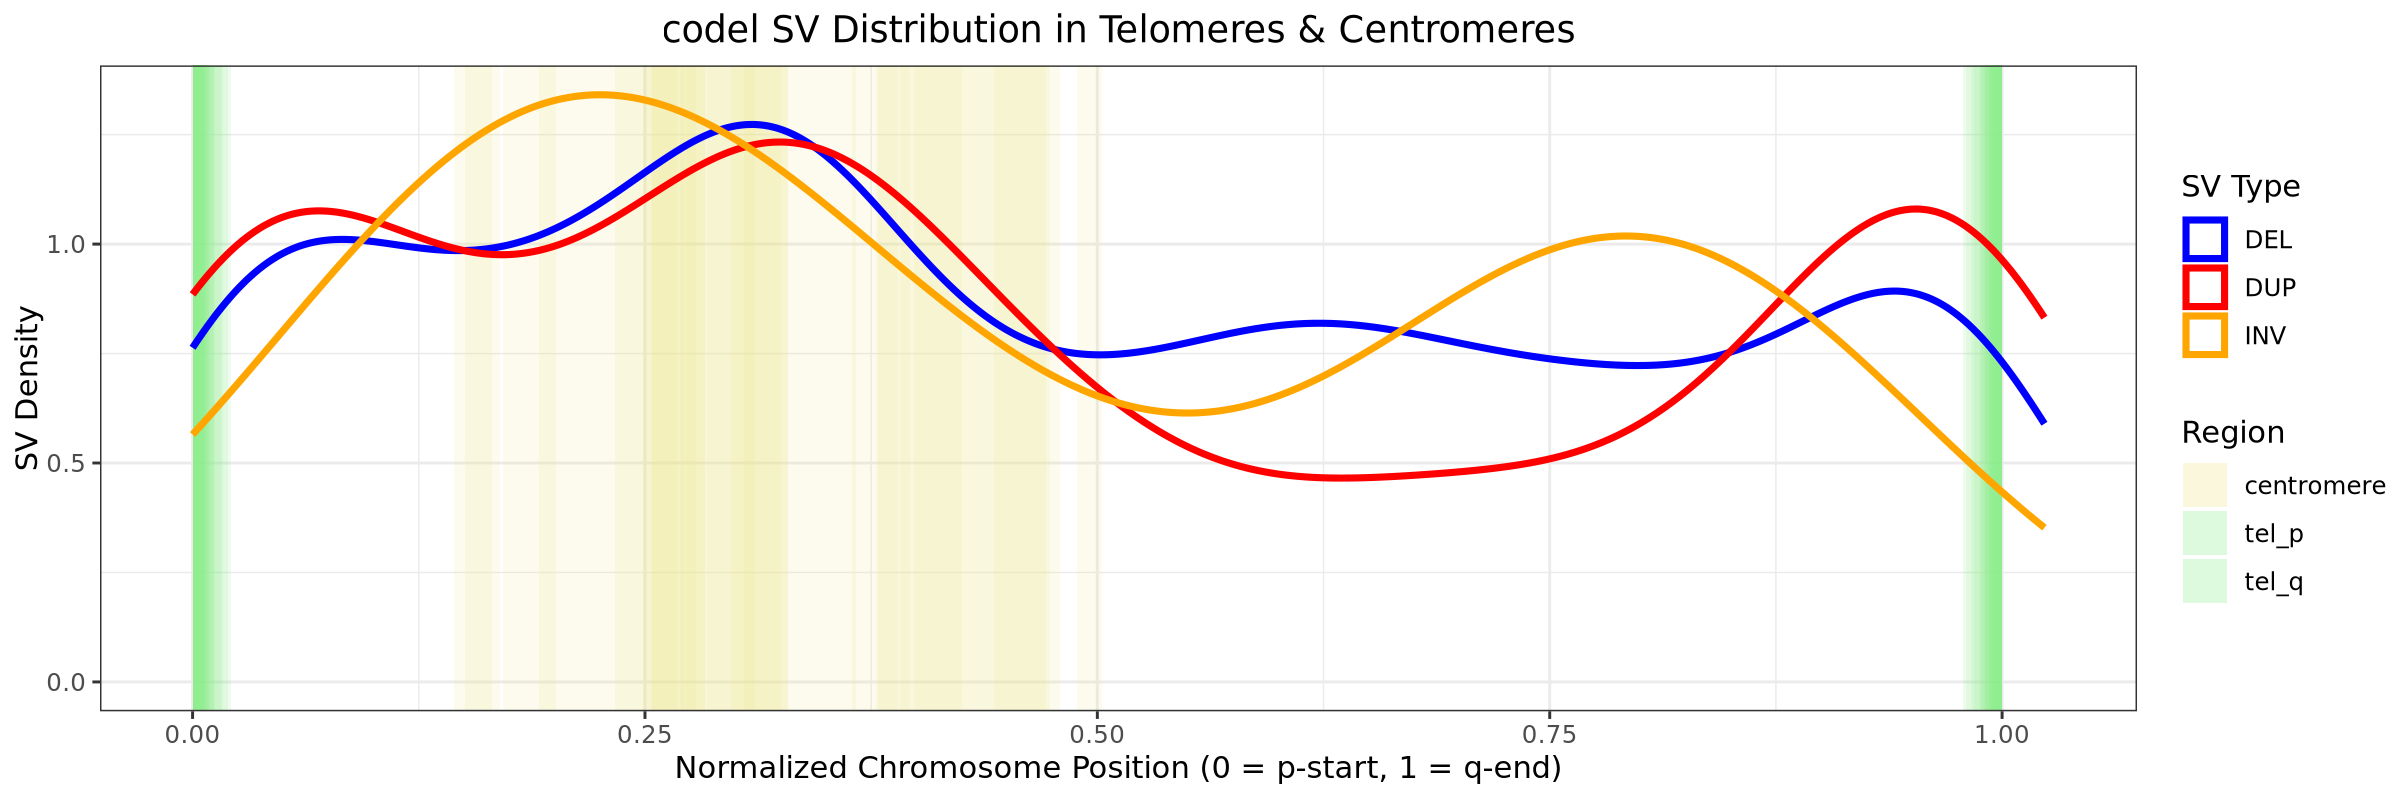

In [70]:

options(repr.plot.width = 12, repr.plot.height = 4, repr.plot.res = 200)

# ——————————————————————————————————————————————
# 6. Plot density with shaded telomeres & centromeres
# ——————————————————————————————————————————————
x <- ggplot(sv_scaled_subtype, aes(x = scaled_pos, color = SV_type.x)) +
  geom_rect(
    data        = shade_regions,
    aes(xmin = xmin, xmax = xmax, ymin = -Inf, ymax = Inf, fill = type),
    inherit.aes = FALSE,
    alpha       = 0.15
  ) +
  geom_density(adjust = 1, size = 1.2, fill = NA) +
  scale_color_manual(
    values = c(DEL = "blue", DUP = "red", INS = "green4", INV = "orange"),
    name   = "SV Type"
  ) +
  scale_fill_manual(
    values = c(centromere = "khaki", tel_p = "lightgreen", tel_q = "lightgreen"),
    guide  = guide_legend(override.aes = list(alpha = 0.3)),
    name   = "Region"
  ) +
  labs(
    x     = "Normalized Chromosome Position (0 = p‐start, 1 = q‐end)",
    y     = "SV Density",
    title = "codel SV Distribution in Telomeres & Centromeres"
  ) +
  theme_bw() +
  theme(
    plot.title    = element_text(hjust = 0.5),
    legend.box    = "vertical",
    legend.margin = margin(5, 5, 5, 5)
  )
x

In [69]:
ggsave(
  #filename = "/scratch/mjehangir/manuscript_figures/Non.codel_scaled_lineplot_SV_density_by_region.pdf",
  plot = x,
  width = 12,
  height = 4,
  dpi = 300
)


ERROR: Error in ggsave(plot = x, width = 12, height = 4, dpi = 300): argument "filename" is missing, with no default


In [73]:
library(tidyverse)

# 1. trim whitespace from your SV‐data chrom names
sv_scaled_subtype <- sv_scaled_subtype %>%
  mutate(seqnames.x = str_trim(seqnames.x))

# 2. keep only autosomes
autosomes <- paste0("chr", 1:22)

sv_facet <- sv_scaled_subtype %>%
  filter(seqnames.x %in% autosomes)

# 3. in your shade table, copy seqnames → seqnames.x via mutate()
shade_facet <- shade_regions %>%
  filter(seqnames %in% autosomes) %>%
  mutate(seqnames.x = seqnames)

In [74]:
head(sv_scaled_subtype)

,sample_id,start.x,end.x,seqnames.x,width.x,disease,SV_type.x,midpoint,chr_length,scaled_pos
,<fct>,<int>,<int>,<chr>,<int>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
1,TCGA-CS-4938-01,66024127,66024568,chr1,442,LGG,DEL,66024348,248956422,0.2652044
2,TCGA-CS-4938-01,144896255,144896495,chr1,241,LGG,DEL,144896375,248956422,0.5820150
3,TCGA-CS-4938-01,67306886,67307152,chr10,267,LGG,DEL,67307019,133797422,0.5030517
4,TCGA-CS-4938-01,70998108,70998554,chr10,447,LGG,DEL,70998331,133797422,0.5306405
5,TCGA-CS-4938-01,97207041,97207421,chr10,381,LGG,DEL,97207231,133797422,0.7265254
6,TCGA-CS-4938-01,29844366,29844588,chr12,223,LGG,DEL,29844477,133275309,0.2239310


Warning message:
“Groups with fewer than two data points have been dropped.”
Warning message:
“Groups with fewer than two data points have been dropped.”
Warning message:
“Groups with fewer than two data points have been dropped.”
Warning message:
“Groups with fewer than two data points have been dropped.”
Warning message:
“Groups with fewer than two data points have been dropped.”
Warning message:
“Groups with fewer than two data points have been dropped.”
Warning message:
“Groups with fewer than two data points have been dropped.”
Warning message:
“Groups with fewer than two data points have been dropped.”
Warning message:
“Groups with fewer than two data points have been dropped.”
Warning message:
“Groups with fewer than two data points have been dropped.”
Warning message in max(ids, na.rm = TRUE):
“no non-missing arguments to max; returning -Inf”
Warning message in max(ids, na.rm = TRUE):
“no non-missing arguments to max; returning -Inf”
Warning message in max(ids, na.rm = TRUE):
“

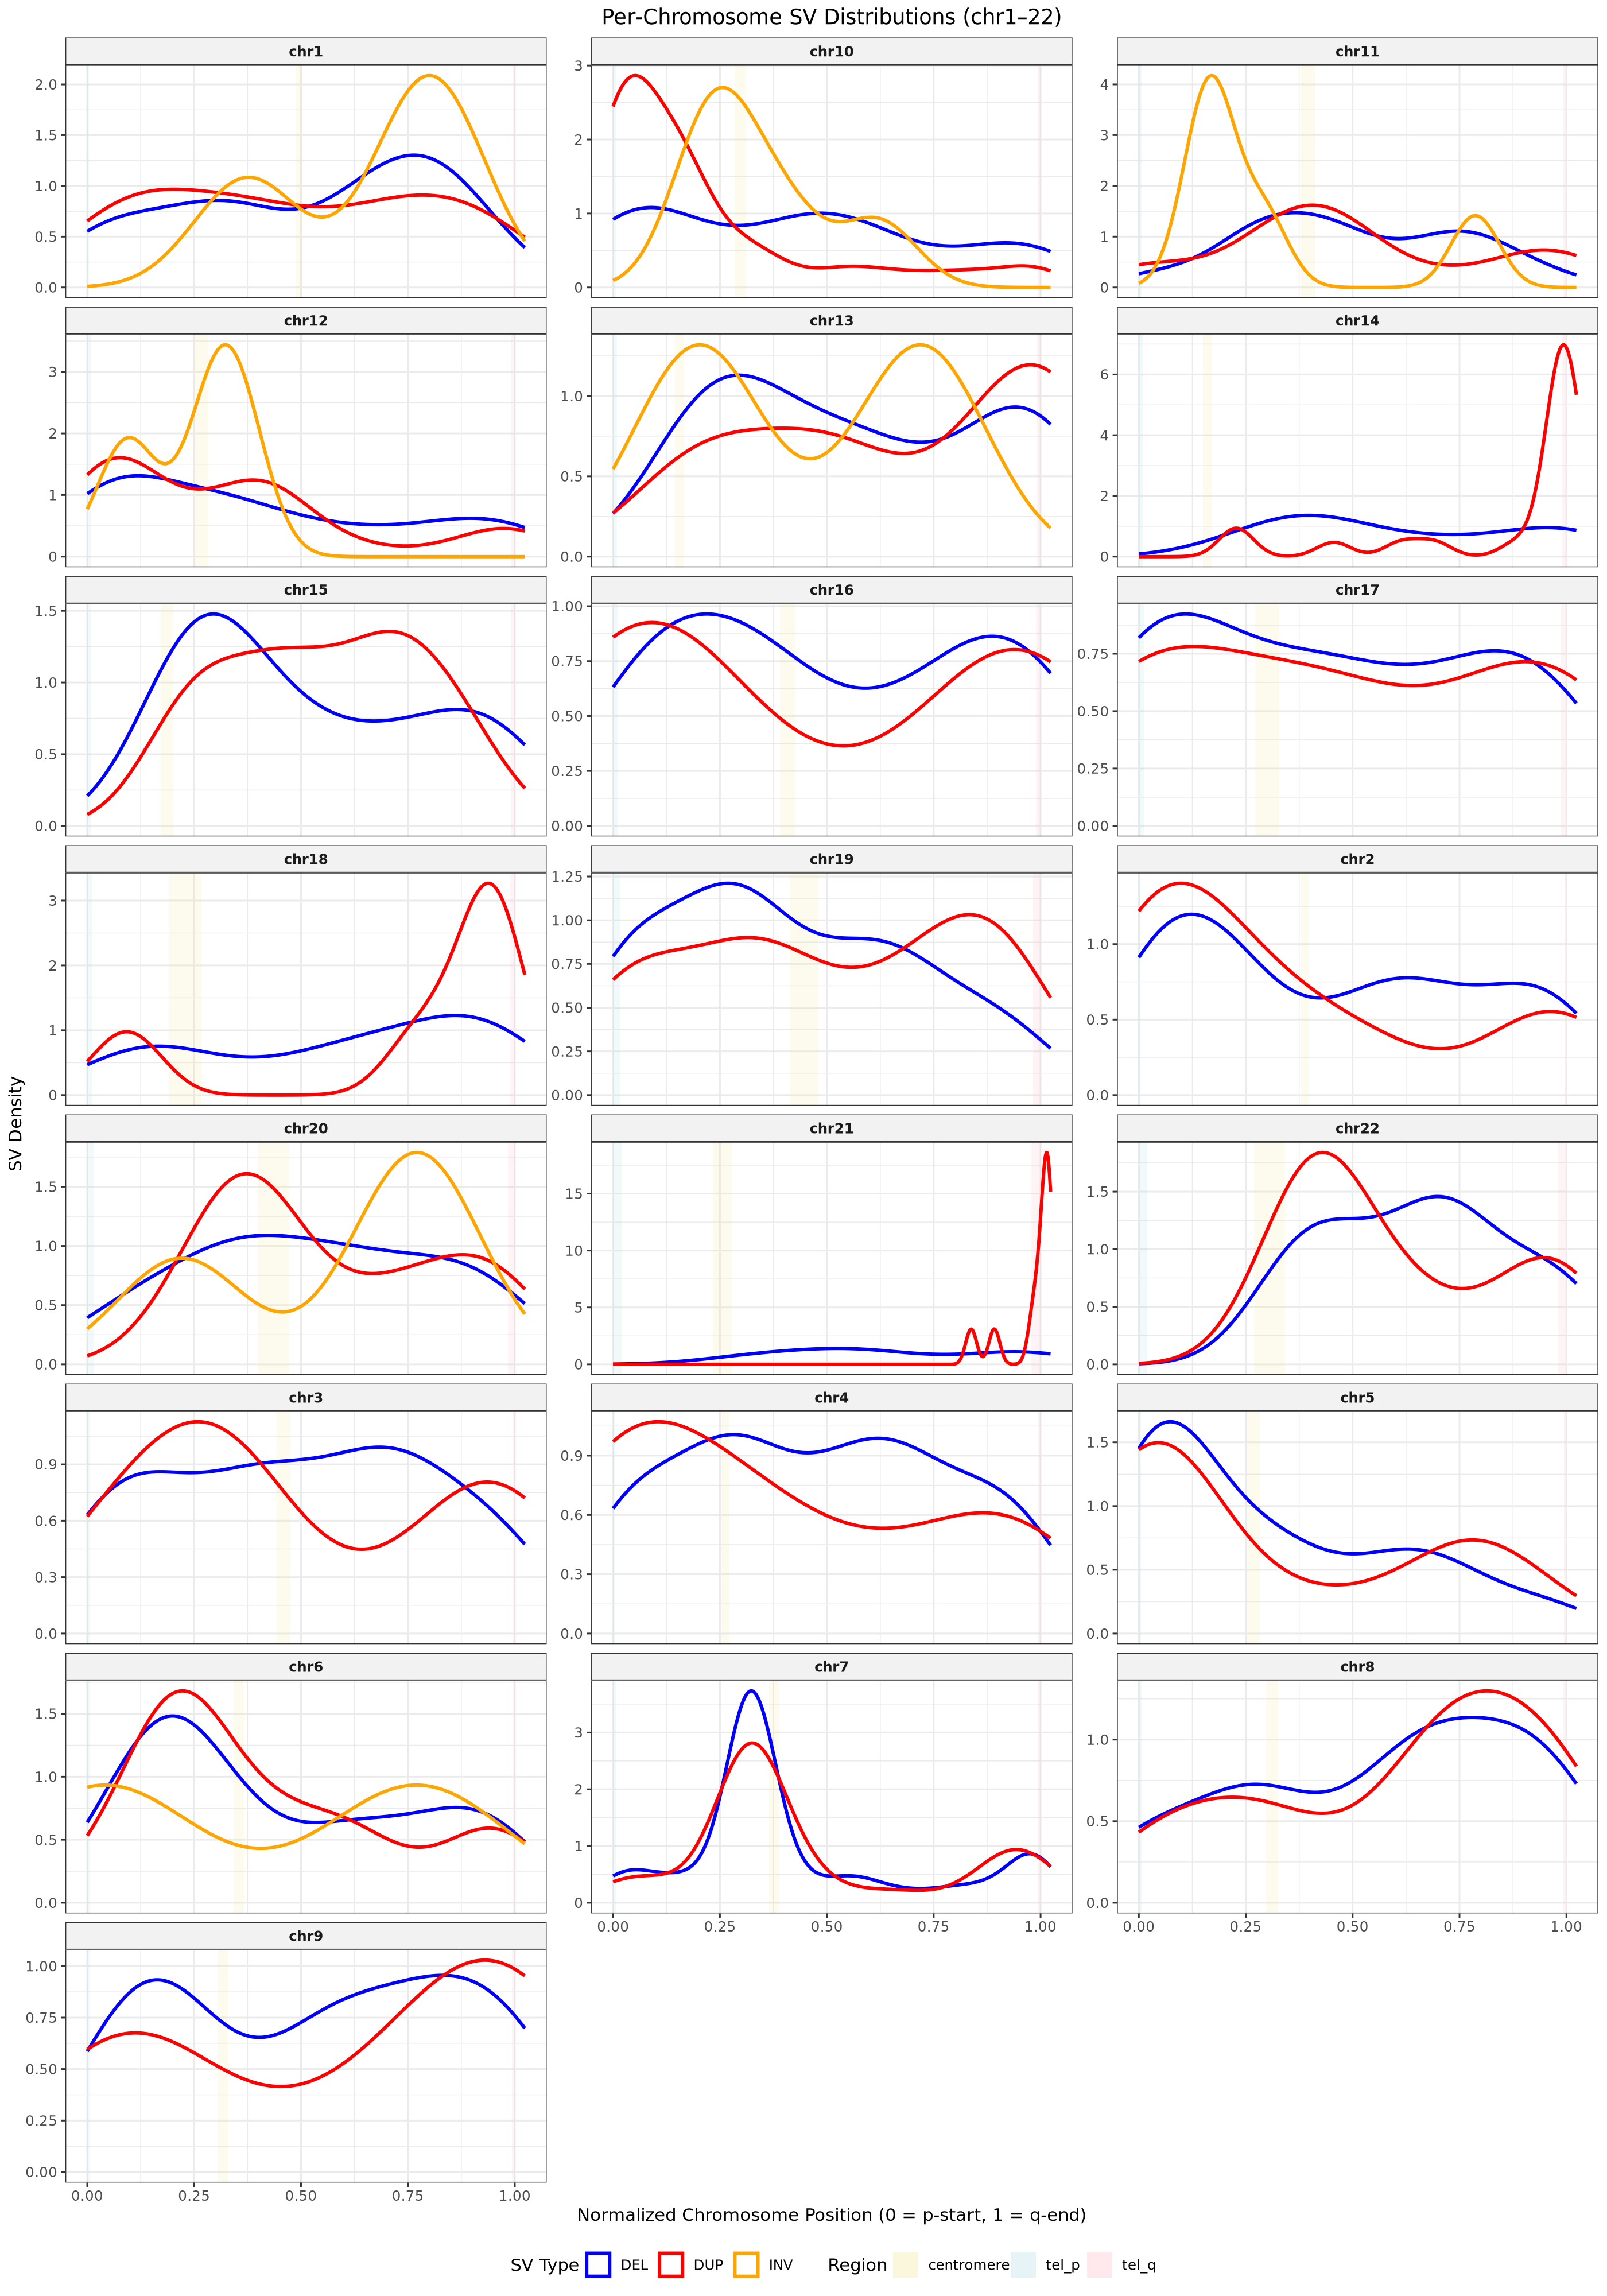

In [75]:

options(repr.plot.width = 14, repr.plot.height = 20, repr.plot.res = 200)
# 4. facet‐wrapped density plot (4 panels per row)
ggplot(sv_facet, aes(x = scaled_pos, color = SV_type.x)) +
  geom_rect(
    data        = shade_facet,
    aes(xmin = xmin, xmax = xmax, ymin = -Inf, ymax = Inf, fill = type),
    inherit.aes = FALSE,
    alpha       = 0.15
  ) +
  geom_density(adjust = 1, size = 1, fill = NA) +
  facet_wrap(~ seqnames.x, ncol = 3, scales = "free_y") +  # free y‐axis per facet
  scale_color_manual(
    values = c(DEL = "blue", DUP = "red", INS = "green4", INV = "orange"),
    name   = "SV Type"
  ) +
  scale_fill_manual(
    values = c(centromere = "khaki", tel_p = "lightblue", tel_q = "lightpink"),
    guide  = guide_legend(override.aes = list(alpha = 0.3)),
    name   = "Region"
  ) +
  labs(
    x     = "Normalized Chromosome Position (0 = p‑start, 1 = q‑end)",
    y     = "SV Density",
    title = "Per‑Chromosome SV Distributions (chr1–22)"
  ) +
  theme_bw() +
  theme(
    plot.title      = element_text(hjust = 0.5),
    strip.background = element_rect(fill = "grey95"),
    strip.text       = element_text(face = "bold"),
    legend.position  = "bottom"
  )


In [76]:
head(sv_scaled_subtype)

,sample_id,start.x,end.x,seqnames.x,width.x,disease,SV_type.x,midpoint,chr_length,scaled_pos
,<fct>,<int>,<int>,<chr>,<int>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
1,TCGA-CS-4938-01,66024127,66024568,chr1,442,LGG,DEL,66024348,248956422,0.2652044
2,TCGA-CS-4938-01,144896255,144896495,chr1,241,LGG,DEL,144896375,248956422,0.5820150
3,TCGA-CS-4938-01,67306886,67307152,chr10,267,LGG,DEL,67307019,133797422,0.5030517
4,TCGA-CS-4938-01,70998108,70998554,chr10,447,LGG,DEL,70998331,133797422,0.5306405
5,TCGA-CS-4938-01,97207041,97207421,chr10,381,LGG,DEL,97207231,133797422,0.7265254
6,TCGA-CS-4938-01,29844366,29844588,chr12,223,LGG,DEL,29844477,133275309,0.2239310


In [79]:
unique(sv_scaled_subtype$seqnames.x)


[1] "chr1"  "chr10" "chr12" "chr13" "chr16" "chr17" "chr18" "chr19" "chr2" 
[10] "chr22" "chr3"  "chr4"  "chr5"  "chr6"  "chr7"  "chr9"  "chr11" "chr15"
[19] "chr8"  "chr14" "chr20" "chr21"

Warning message in wilcox.test.default(c(0.00695651805641027, 0.0139130361128205, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0.00695651805641027, 0.0278260722256411, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0.00695651805641027, 0.0278260722256411, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0.00508060307490638, 0.00312652496917315, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0.00695651805641027, 0.00695651805641027:
“cannot compute exact p-value with ties”
Warning message:
“Computation failed in `stat_signif()`.
Caused by error in `wilcox.test.default()`:
! not enough 'y' observations”


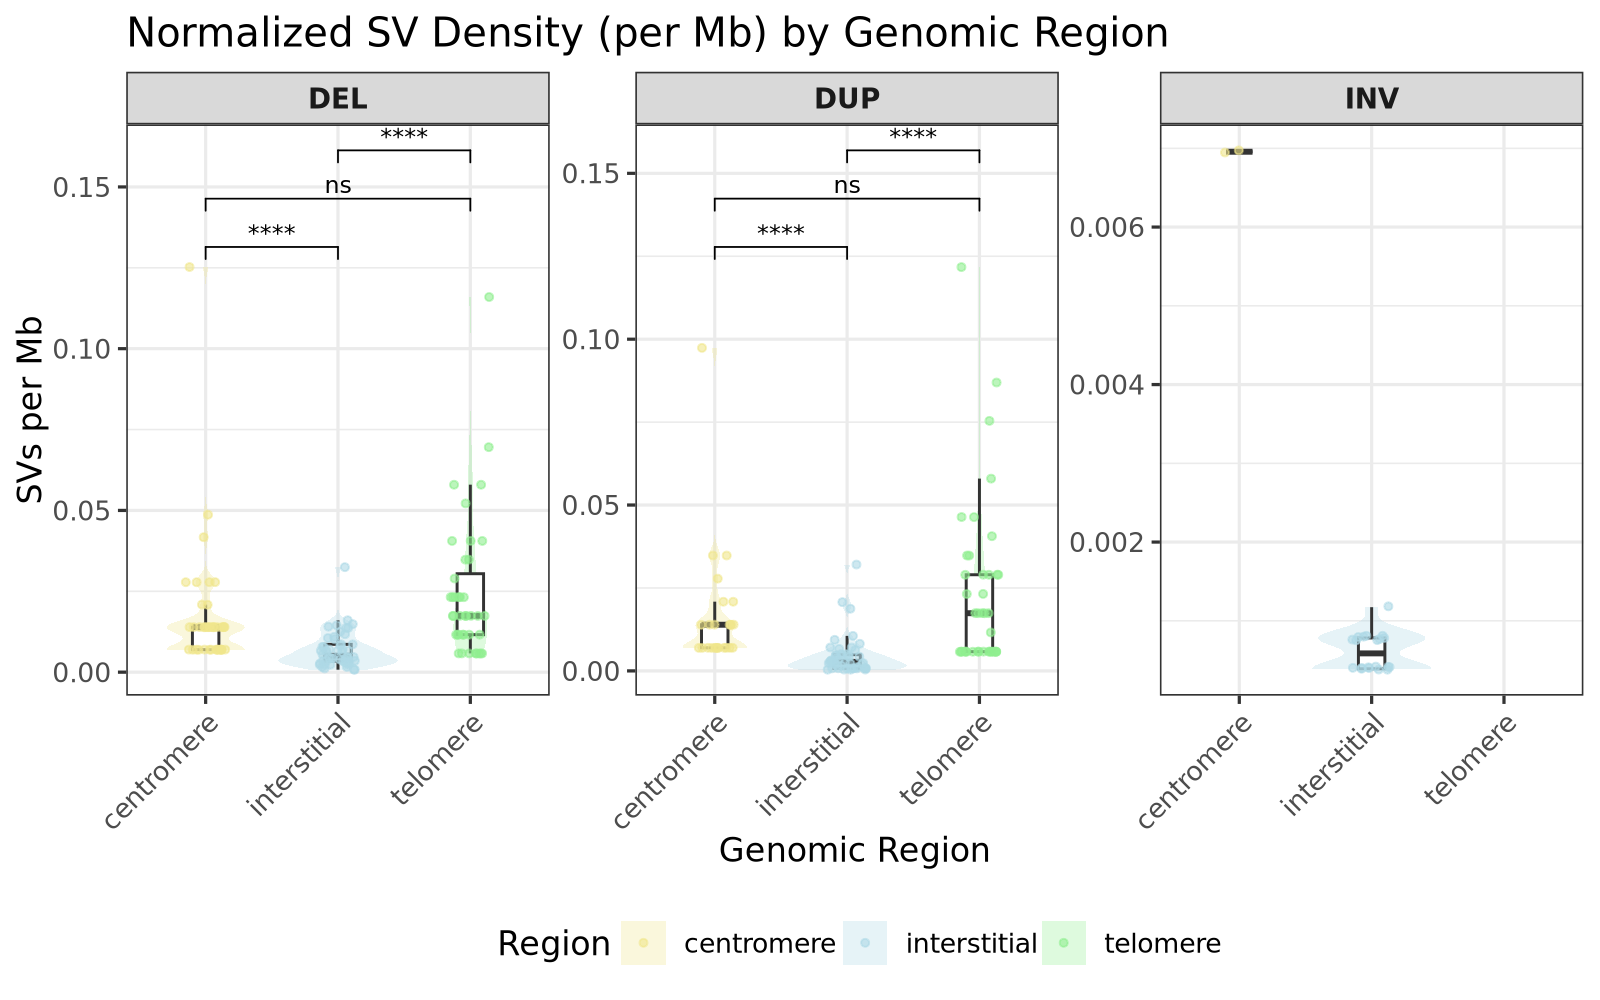

In [83]:
library(dplyr)
library(tidyr)
library(ggplot2)
library(ggpubr)
library(ggbeeswarm)

# Step 1: Define centromere positions (example for GRCh38)
centromere_positions <- tibble::tibble(
  chrom = paste0("chr", 1:22),
  centromere_pos = c(
    123400000, 93900000, 90900000, 50000000, 48800000,
    59800000, 60100000, 45200000, 47600000, 39200000,
    51600000, 34800000, 16000000, 16000000, 17000000,
    36600000, 24000000, 17200000, 26500000, 27500000,
    13200000, 13900000
  )
)

# Step 2: Classify SVs by genomic region
sv_with_region <- sv_scaled_subtype %>%
  dplyr::rename(chrom = seqnames.x, type = SV_type.x) %>%
  left_join(centromere_positions, by = "chrom") %>%
  mutate(
    centromere_scaled = centromere_pos / chr_length,
    region = case_when(
      scaled_pos <= 0.03 | scaled_pos >= 0.97 ~ "telomere",
      abs(scaled_pos - centromere_scaled) < 0.05 ~ "centromere",
      TRUE ~ "interstitial"
    ),
    region = factor(region, levels = c("centromere", "interstitial", "telomere")),
    chrom = factor(chrom, levels = paste0("chr", 1:22)),
    type = factor(type)
  )

# Step 3: Estimate total region lengths across all autosomes
region_lengths <- sv_with_region %>%
  distinct(chrom, chr_length, centromere_pos) %>%
  mutate(
    telo_length = chr_length * 0.03 * 2,
    centro_length = chr_length * 0.05,
    interstitial_length = chr_length - telo_length - centro_length
  ) %>%
  summarise(
    telomere = sum(telo_length),
    centromere = sum(centro_length),
    interstitial = sum(interstitial_length),
    .groups = "drop"
  ) %>%
  pivot_longer(cols = everything(), names_to = "region", values_to = "length") %>%
  mutate(length_mb = length / 1e6)

# Step 4: Count SVs per sample, region, and type
sv_counts <- sv_with_region %>%
  group_by(sample_id, region, type) %>%
  summarise(sv_count = n(), .groups = "drop") %>%
  left_join(region_lengths, by = "region") %>%
  mutate(count_per_mb = sv_count / length_mb)

# Step 5: Plotting
my_comparisons <- list(
  c("centromere", "interstitial"),
  c("centromere", "telomere"),
  c("interstitial", "telomere")
)

options(repr.plot.width = 8, repr.plot.height = 5, repr.plot.res = 200)

sv_density_plot <- ggplot(sv_counts, aes(x = region, y = count_per_mb, fill = region)) +
  geom_violin(alpha = 0.3, color = NA) +
  geom_boxplot(width = 0.2, fill = "white", outlier.shape = NA) +
  geom_jitter(aes(color = region), width = 0.15, alpha = 0.6, size = 1) +
  facet_wrap(~type, scales = "free_y") +
  stat_compare_means(comparisons = my_comparisons, method = "wilcox.test", label = "p.signif", size = 3) +
  scale_fill_manual(values = c(
    centromere = "khaki",
    interstitial = "lightblue",
    telomere = "lightgreen"
  )) +
  scale_color_manual(values = c(
    centromere = "khaki",
    interstitial = "lightblue",
    telomere = "lightgreen"
  )) +
  labs(
    title = "Normalized SV Density (per Mb) by Genomic Region",
    x = "Genomic Region",
    y = "SVs per Mb",
    fill = "Region",
    color = "Region"
  ) +
  theme_bw(base_size = 12) +
  theme(
    strip.text = element_text(face = "bold", size = 10),
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.position = "bottom"
  )

sv_density_plot

In [ ]:
ggsave(
  filename = "/scratch/mjehangir/manuscript_figures/Non.codel_SV_density_by_region.pdf",
  plot = sv_density_plot,
  width = 8,
  height = 5,
  dpi = 300
)


In [84]:
# Standardize category labels
telomere_data <- sv_tel_summary %>%
  mutate(category = case_when(
    tolower(category) == "codel" ~ "Codel",
    tolower(category) == "non.codel" ~ "Non-codel",
    tolower(category) == "wt" ~ "WT",
    TRUE ~ category
  ))


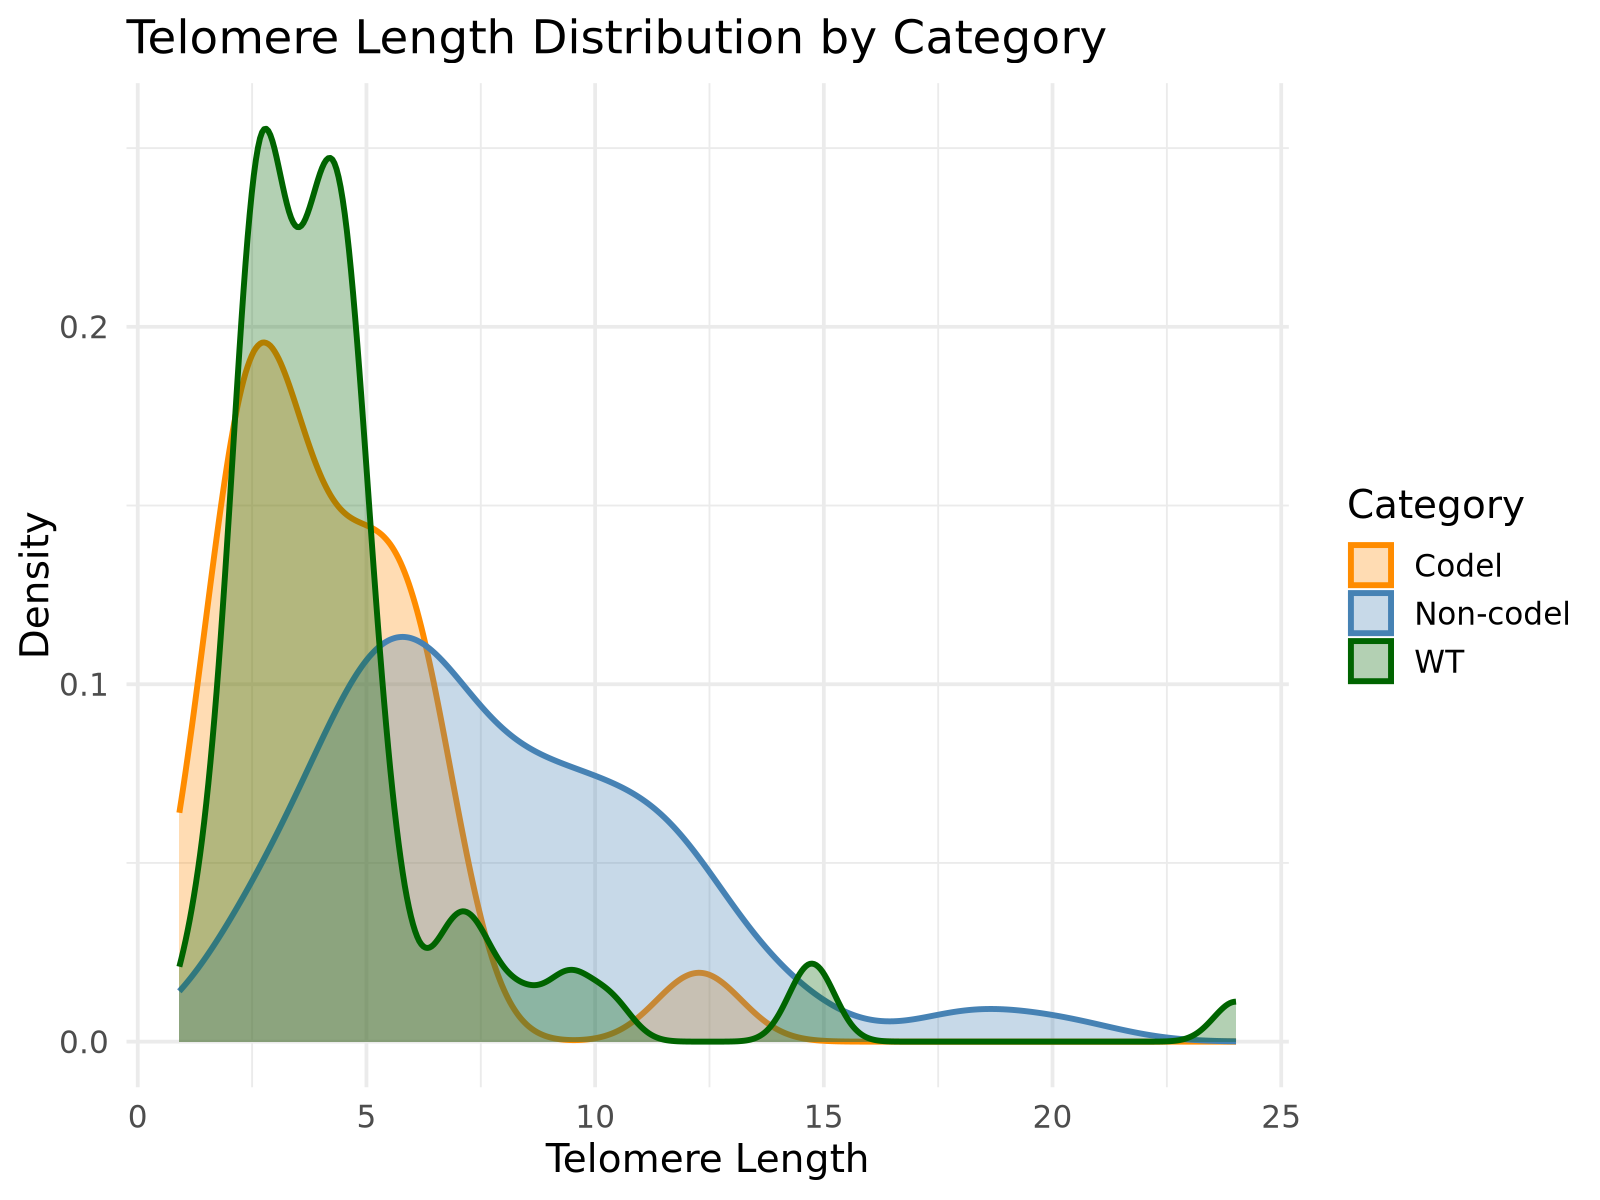

In [85]:
options(repr.plot.width = 8, repr.plot.height = 6, repr.plot.res = 200)

ggplot(telomere_data, aes(x = tlen, fill = category, color = category)) +
  geom_density(alpha = 0.3, linewidth = 1) +
  theme_minimal(base_size = 14) +
  labs(
    title = "Telomere Length Distribution by Category",
    x = "Telomere Length",
    y = "Density",
    fill = "Category",
    color = "Category"
  ) +
  scale_fill_manual(values = c("Codel" = "darkorange", "Non-codel" = "steelblue", "WT" = "darkgreen")) +
  scale_color_manual(values = c("Codel" = "darkorange", "Non-codel" = "steelblue", "WT" = "darkgreen"))


In [86]:
telomere_data %>%
  group_by(category) %>%
  summarise(n_patients = n_distinct(patient_id))


category,n_patients
<chr>,<int>
Codel,22
Non-codel,52
WT,59


In [87]:
head(sv_tel_summary)

patient_id,SV_type.x,SV_count,Total_width,telomere_diff,nlen,tlen,SV_density,SV_proportion,category
<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
TCGA-02-2483,DEL,24,1877,0.9864312,6.066187,5.079756,6.054839e-07,7.741935e-09,Non.codel
TCGA-02-2483,DUP,34,4168,0.9864312,6.066187,5.079756,1.344516e-06,1.096774e-08,Non.codel
TCGA-02-2483,INV,3,29,0.9864312,6.066187,5.079756,9.354839e-09,9.677419e-10,Non.codel
TCGA-02-2485,DEL,27,4874,-8.5896257,6.038091,14.627717,1.572258e-06,8.709677e-09,WT
TCGA-02-2485,DUP,27,4787,-8.5896257,6.038091,14.627717,1.544194e-06,8.709677e-09,WT
TCGA-06-0124,DEL,21,2426,0.2810998,3.239151,2.958051,7.825806e-07,6.774194e-09,WT


[1] "Non.codel" "WT"        "codel"    
# A tibble: 3 × 5
  category  mean_tel_diff median_tel_diff sd_tel_diff     n
  <chr>             <dbl>           <dbl>       <dbl> <int>
1 Non.codel        -2.36            -2.04        3.58   124
2 WT                0.669            1.37        3.42   147
3 codel             1.65             1.92        2.05    45
# A tibble: 6 × 3
  category  tel_length_status total_SV
  <chr>     <chr>                <int>
1 Non.codel Tumor_Longer          1600
2 Non.codel Tumor_Shorter          468
3 WT        Tumor_Longer           760
4 WT        Tumor_Shorter         2810
5 codel     Tumor_Longer            84
6 codel     Tumor_Shorter          586
# A tibble: 17 × 5
# Groups:   category, tel_length_status [6]
   category  tel_length_status SV_type.x total_SV   prop
   <chr>     <chr>             <chr>        <int>  <dbl>
 1 Non.codel Tumor_Longer      DEL            964 0.602 
 2 Non.codel Tumor_Longer      DUP            617 0.386 
 3 Non.codel Tumor_Lo

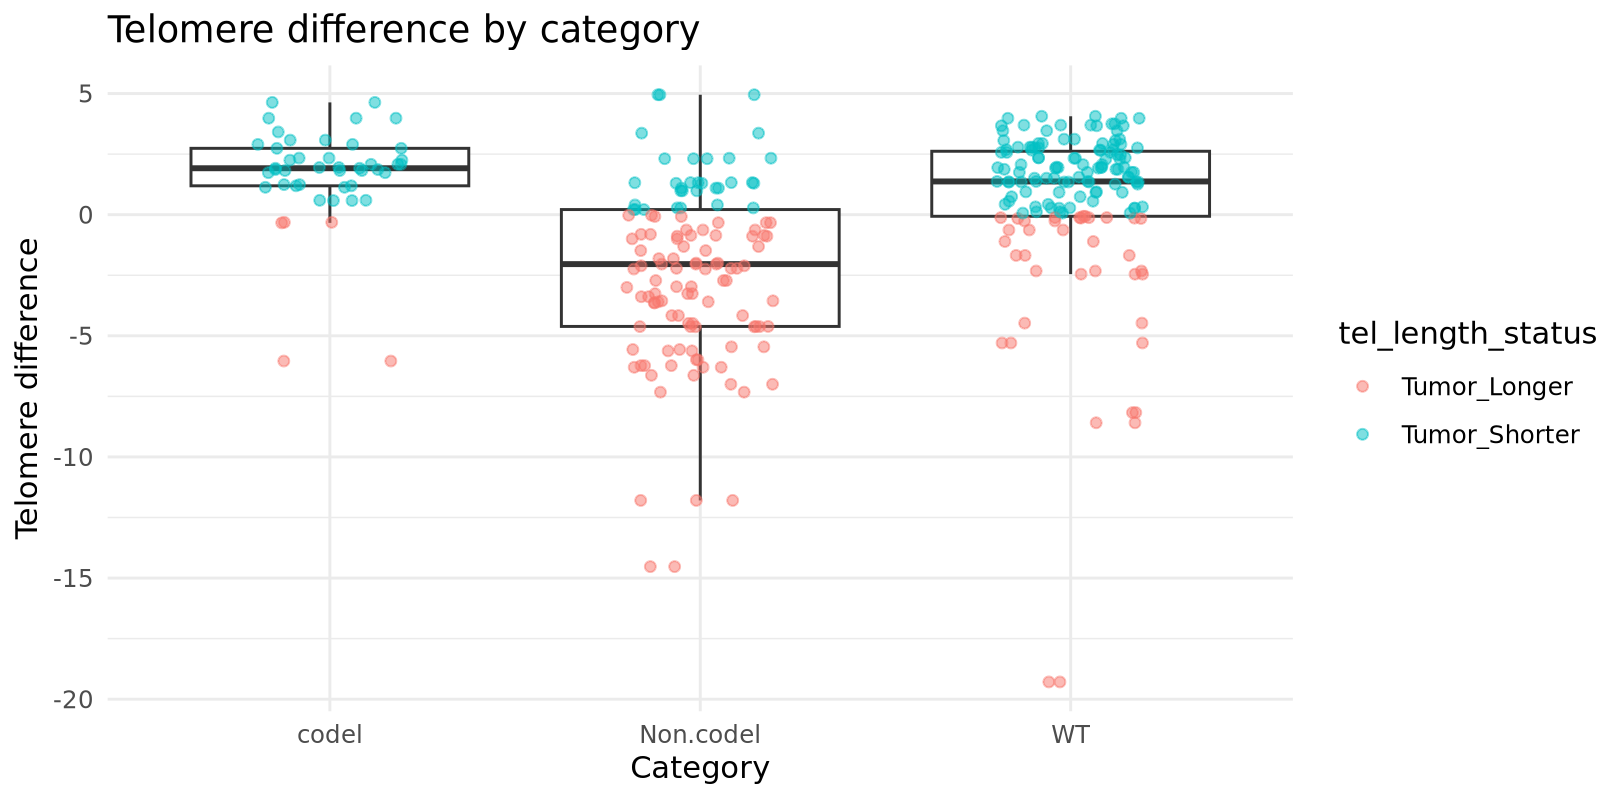

In [88]:
library(dplyr)
library(ggplot2)

# 1. Check all categories available
all_categories <- unique(sv_tel_summary$category)
print(all_categories)

sv_tel_summary <- sv_tel_summary %>%
  mutate(tel_length_status = case_when(
    telomere_diff > 0  ~ "Tumor_Shorter",
    telomere_diff < 0  ~ "Tumor_Longer",
    TRUE               ~ "No_change"
  ))


# 3. Summary stats of telomere difference by category
tel_summary <- sv_tel_summary %>%
  group_by(category) %>%
  summarise(
    mean_tel_diff = mean(telomere_diff, na.rm = TRUE),
    median_tel_diff = median(telomere_diff, na.rm = TRUE),
    sd_tel_diff = sd(telomere_diff, na.rm = TRUE),
    n = n()
  )
print(tel_summary)

# 4. Count SV events by telomere length status and category
tel_length_counts <- sv_tel_summary %>%
  group_by(category, tel_length_status) %>%
  summarise(total_SV = sum(SV_count), .groups = "drop")
print(tel_length_counts)

# 5. For each telomere length status (Longer, Shorter), calculate SV type proportions within each category

sv_props_by_length <- sv_tel_summary %>%
  filter(tel_length_status != "No_change") %>%  # exclude no_change
  group_by(category, tel_length_status, SV_type.x) %>%
  summarise(total_SV = sum(SV_count), .groups = "drop") %>%
  group_by(category, tel_length_status) %>%
  mutate(prop = total_SV / sum(total_SV))

print(sv_props_by_length)
options(repr.plot.width = 8, repr.plot.height = 4, repr.plot.res = 200)

# 6. Visualize telomere difference by category
ggplot(sv_tel_summary, aes(x = category, y = telomere_diff)) +
  geom_boxplot(outlier.shape = NA) +
  geom_jitter(width = 0.2, alpha = 0.5, aes(color = tel_length_status)) +
  labs(title = "Telomere difference by category",
       y = "Telomere difference", x = "Category") +
  theme_minimal()





Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor




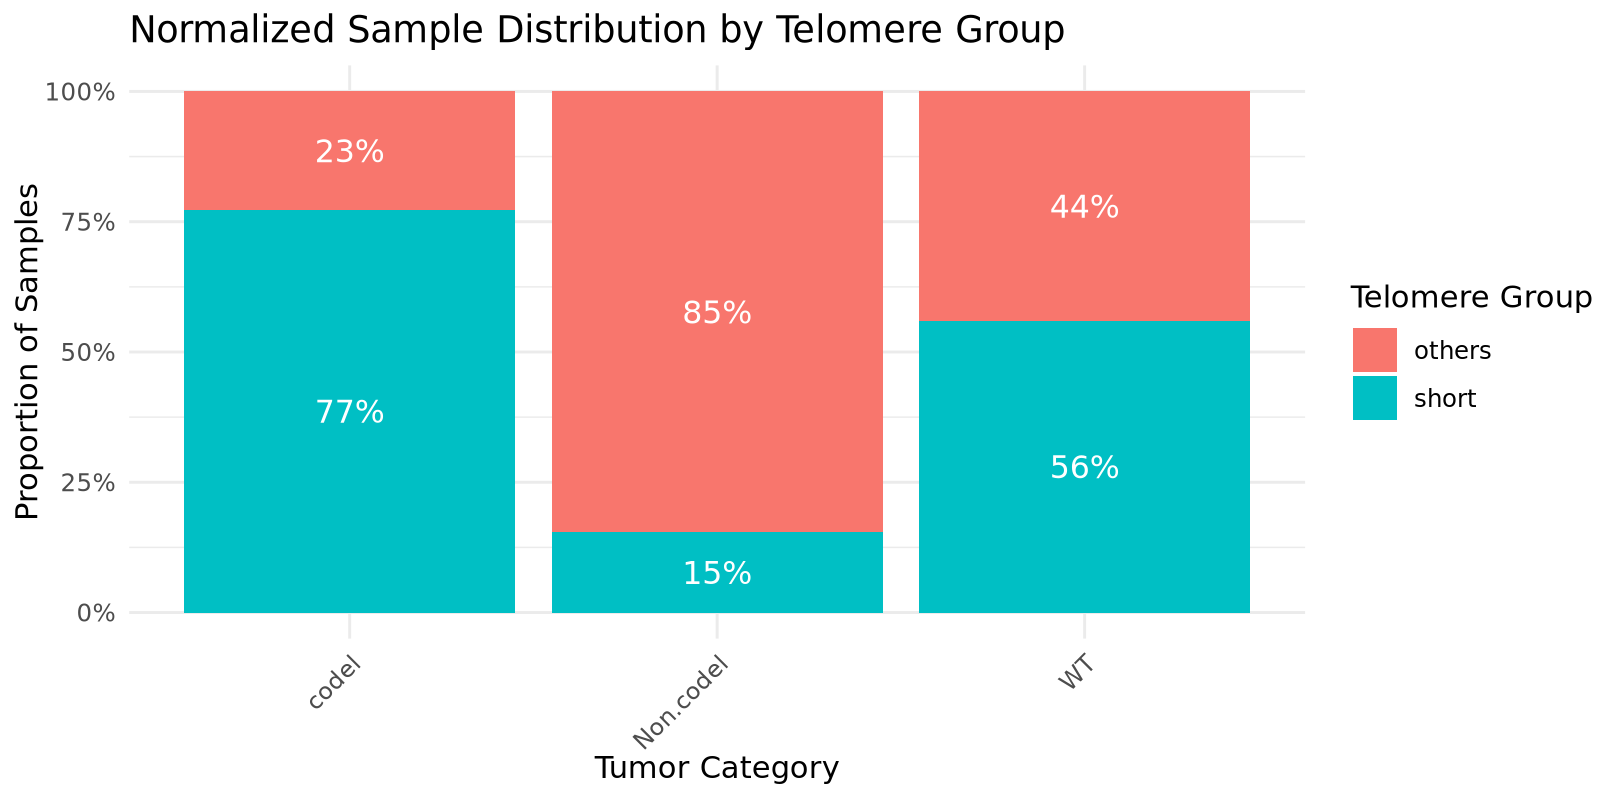

In [89]:
library(dplyr)
library(ggplot2)
library(scales)

# Step 1: Define tel_group if not yet defined
sv_tel_summary <- sv_tel_summary %>%
  mutate(tel_group = ifelse(telomere_diff > 1, "short", "others"))

# Step 2: Count unique samples per category and tel_group
sample_counts <- sv_tel_summary %>%
  select(patient_id, category, tel_group) %>%
  distinct() %>%
  group_by(category, tel_group) %>%
  summarise(n_samples = n(), .groups = "drop") %>%
  group_by(category) %>%
  mutate(
    proportion = n_samples / sum(n_samples),
    label = percent(proportion, accuracy = 1)
  ) %>%
  ungroup()

# Step 3: Plot with percentage labels
ggplot(sample_counts, aes(x = category, y = proportion, fill = tel_group)) +
  geom_bar(stat = "identity", position = "fill") +
  geom_text(aes(label = label), 
            position = position_fill(vjust = 0.5), 
            color = "white", size = 4) +
  labs(
    title = "Normalized Sample Distribution by Telomere Group",
    x = "Tumor Category",
    y = "Proportion of Samples",
    fill = "Telomere Group"
  ) +
  scale_y_continuous(labels = percent_format(accuracy = 1)) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))


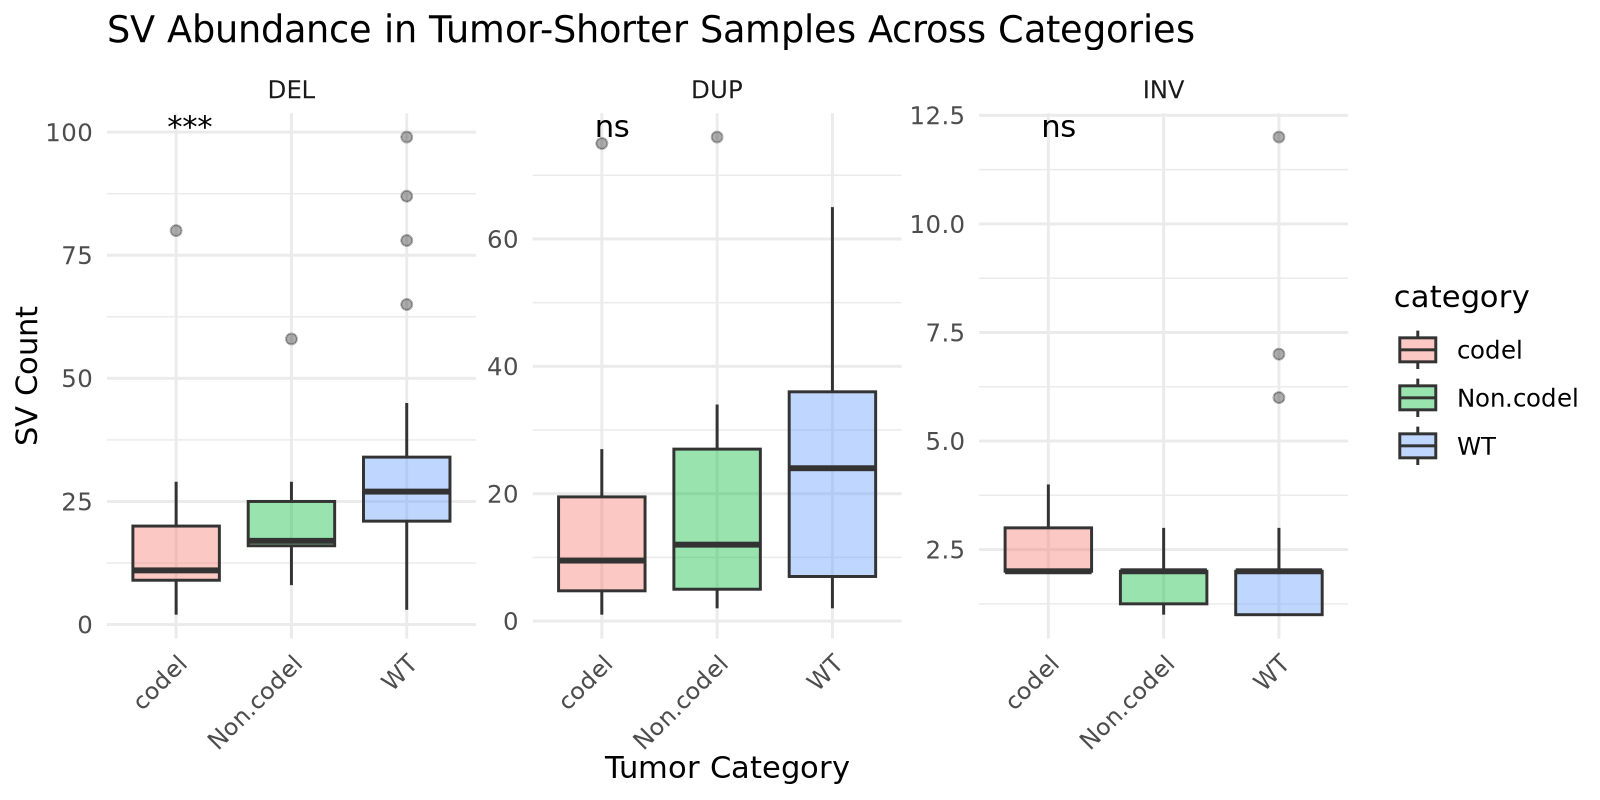

In [90]:
library(dplyr)
library(ggplot2)
library(ggpubr)

# Step 1: Filter to tumor-shorter samples only
short_tel <- sv_tel_summary %>%
  filter(telomere_diff > 0.5)

# Step 2: Summarize total SV count per patient, SV type, and category
short_summary <- short_tel %>%
  group_by(patient_id, SV_type.x, category) %>%
  summarise(SV_count = sum(SV_count), .groups = "drop")
options(repr.plot.width = 8, repr.plot.height = 4, repr.plot.res = 200)

# Step 3: Plot SV abundance per category
ggplot(short_summary, aes(x = category, y = SV_count, fill = category)) +
  geom_boxplot(alpha = 0.4) +
  facet_wrap(~ SV_type.x, scales = "free_y") +
  stat_compare_means(method = "kruskal.test", label = "p.signif") +
  labs(
    title = "SV Abundance in Tumor-Shorter Samples Across Categories",
    x = "Tumor Category",
    y = "SV Count"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))


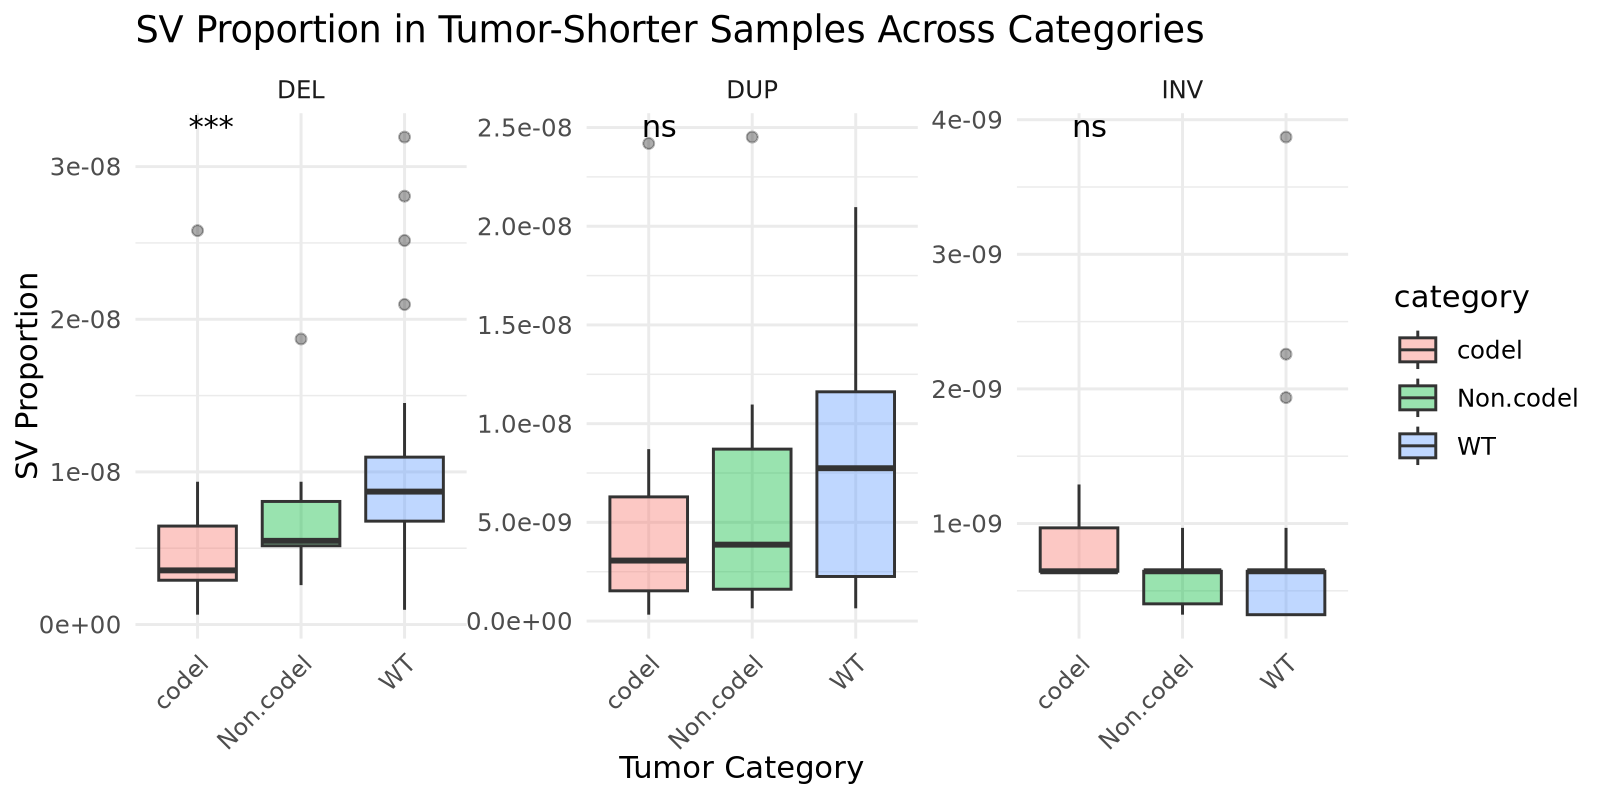

In [91]:
options(repr.plot.width = 8, repr.plot.height = 4, repr.plot.res = 200)

# Step 1: Summarize SV_proportion
short_prop_summary <- short_tel %>%
  group_by(patient_id, SV_type.x, category) %>%
  summarise(SV_proportion = mean(SV_proportion, na.rm = TRUE), .groups = "drop")

# Step 2: Plot
ggplot(short_prop_summary, aes(x = category, y = SV_proportion, fill = category)) +
  geom_boxplot(alpha = 0.4) +
  facet_wrap(~ SV_type.x, scales = "free_y") +
  stat_compare_means(method = "kruskal.test", label = "p.signif") +
  labs(
    title = "SV Proportion in Tumor-Shorter Samples Across Categories",
    x = "Tumor Category",
    y = "SV Proportion"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))


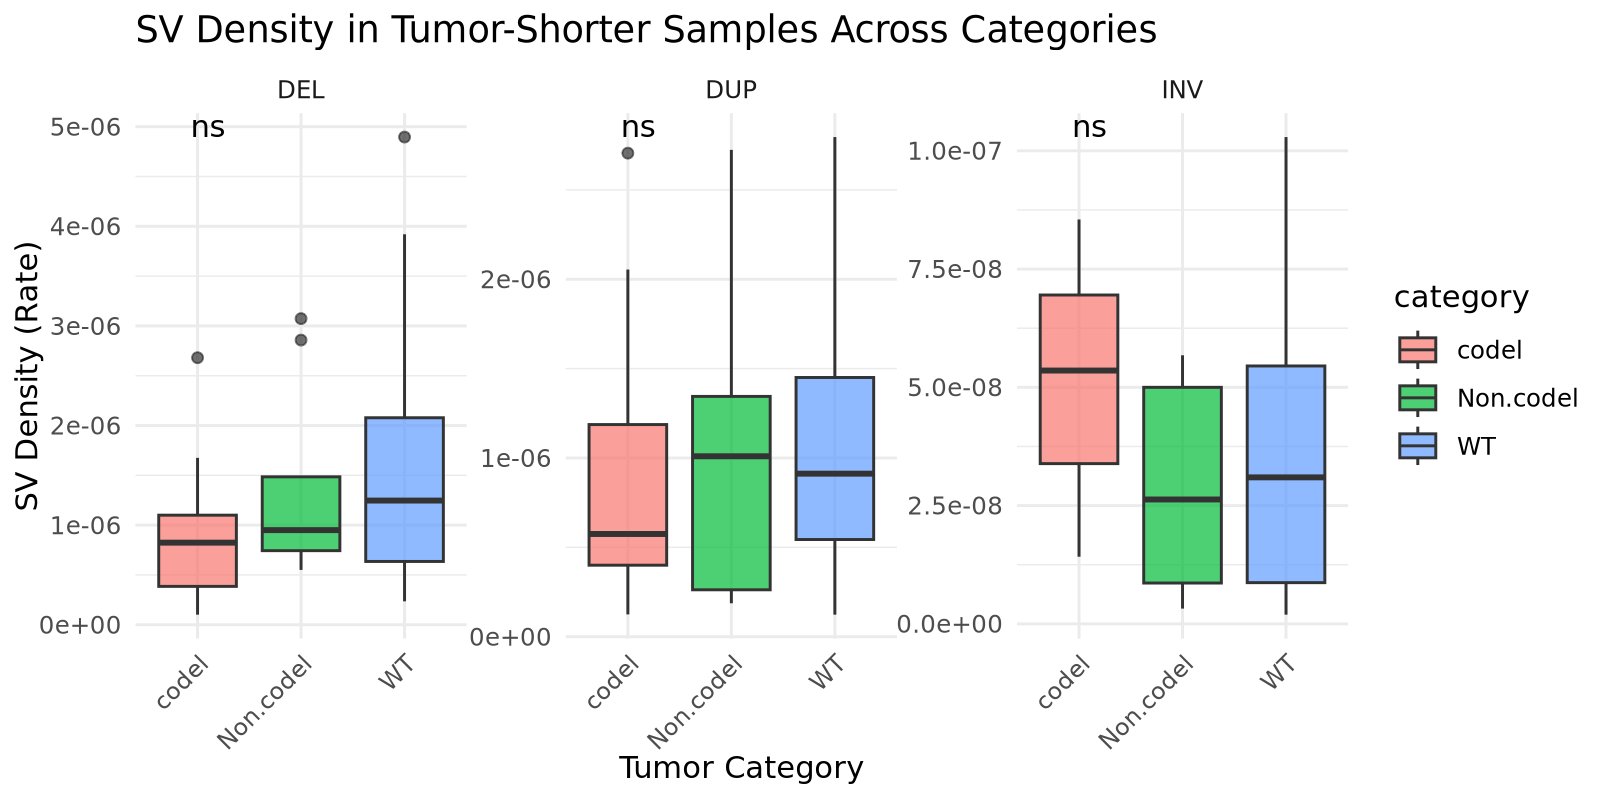

In [92]:
options(repr.plot.width = 8, repr.plot.height = 4, repr.plot.res = 200)

# Step 1: Summarize SV_density
short_density_summary <- short_tel %>%
  group_by(patient_id, SV_type.x, category) %>%
  summarise(SV_density = mean(SV_density, na.rm = TRUE), .groups = "drop")

# Step 2: Plot
ggplot(short_density_summary, aes(x = category, y = SV_density, fill = category)) +
  geom_boxplot(alpha = 0.7) +
  facet_wrap(~ SV_type.x, scales = "free_y") +
  stat_compare_means(method = "kruskal.test", label = "p.signif") +
  labs(
    title = "SV Density in Tumor-Shorter Samples Across Categories",
    x = "Tumor Category",
    y = "SV Density (Rate)"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))


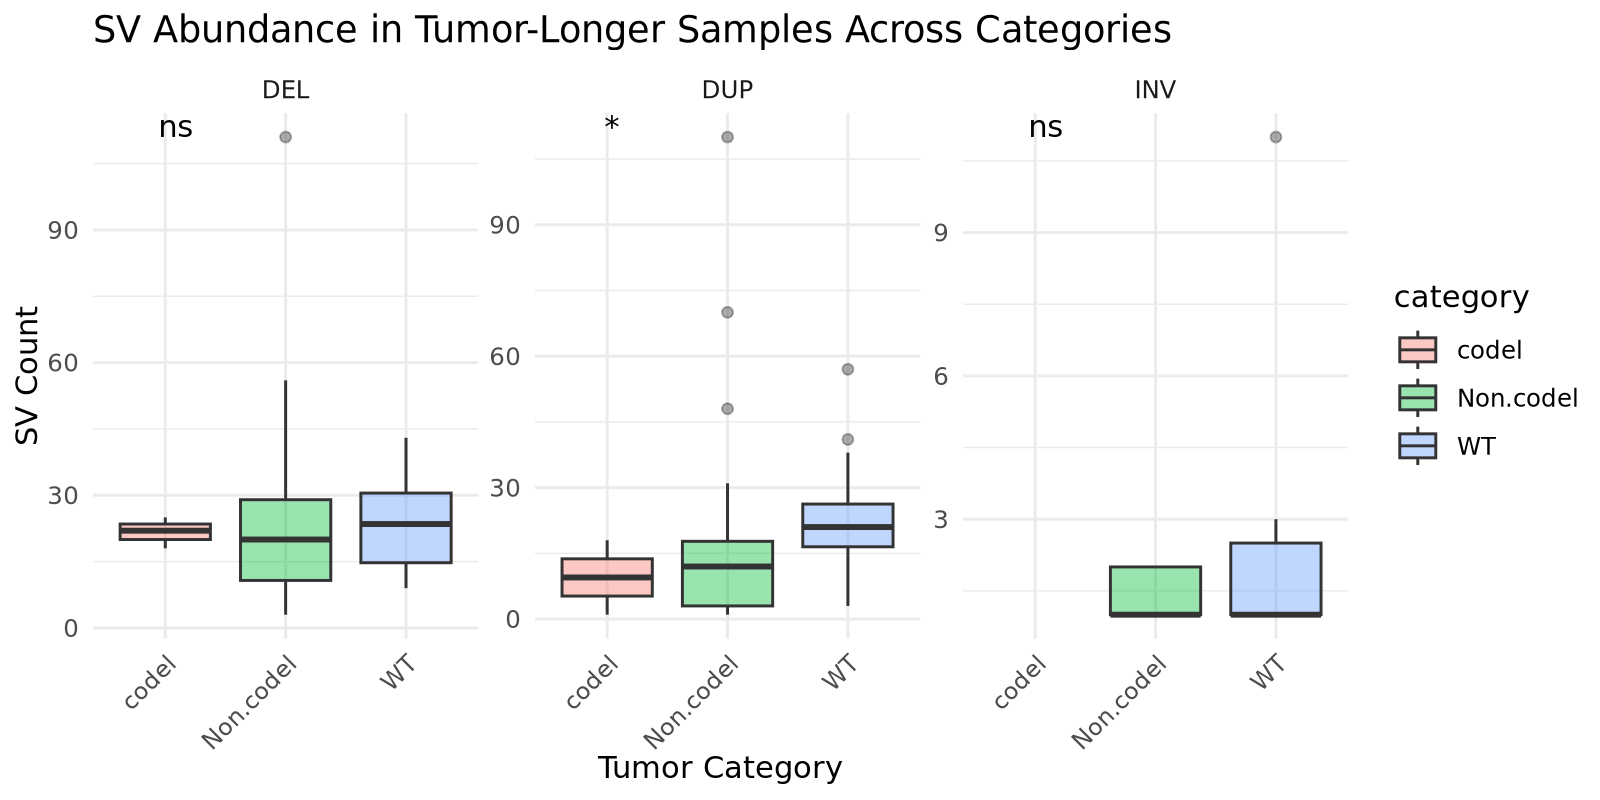

In [93]:
library(dplyr)
library(ggplot2)
library(ggpubr)

# Step 1: Filter to tumor-longer samples only
long_tel <- sv_tel_summary %>%
  filter(telomere_diff < 0)

# Step 2: Summarize SV counts per patient, SV type, and category
long_summary <- long_tel %>%
  group_by(patient_id, SV_type.x, category) %>%
  summarise(SV_count = sum(SV_count), .groups = "drop")

# Step 3: Plot SV abundance across categories
ggplot(long_summary, aes(x = category, y = SV_count, fill = category)) +
  geom_boxplot(alpha = 0.4) +
  facet_wrap(~ SV_type.x, scales = "free_y") +
  stat_compare_means(method = "kruskal.test", label = "p.signif") +
  labs(
    title = "SV Abundance in Tumor-Longer Samples Across Categories",
    x = "Tumor Category",
    y = "SV Count"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))


In [94]:
head(short_tel)
nrow(short_tel)
nrow(long_tel)


patient_id,SV_type.x,SV_count,Total_width,telomere_diff,nlen,tlen,SV_density,SV_proportion,category,tel_length_status,tel_group
<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
TCGA-02-2483,DEL,24,1877,0.9864312,6.066187,5.079756,6.054839e-07,7.741935e-09,Non.codel,Tumor_Shorter,others
TCGA-02-2483,DUP,34,4168,0.9864312,6.066187,5.079756,1.344516e-06,1.096774e-08,Non.codel,Tumor_Shorter,others
TCGA-02-2483,INV,3,29,0.9864312,6.066187,5.079756,9.354839e-09,9.677419e-10,Non.codel,Tumor_Shorter,others
TCGA-06-0125,DEL,34,2140,3.7494293,6.473299,2.723869,6.903226e-07,1.096774e-08,WT,Tumor_Shorter,short
TCGA-06-0125,DUP,49,5832,3.7494293,6.473299,2.723869,1.881290e-06,1.580645e-08,WT,Tumor_Shorter,short
TCGA-06-0128,DEL,16,1706,4.9508334,7.624396,2.673563,5.503226e-07,5.161290e-09,Non.codel,Tumor_Shorter,short


[1] 159

[1] 135

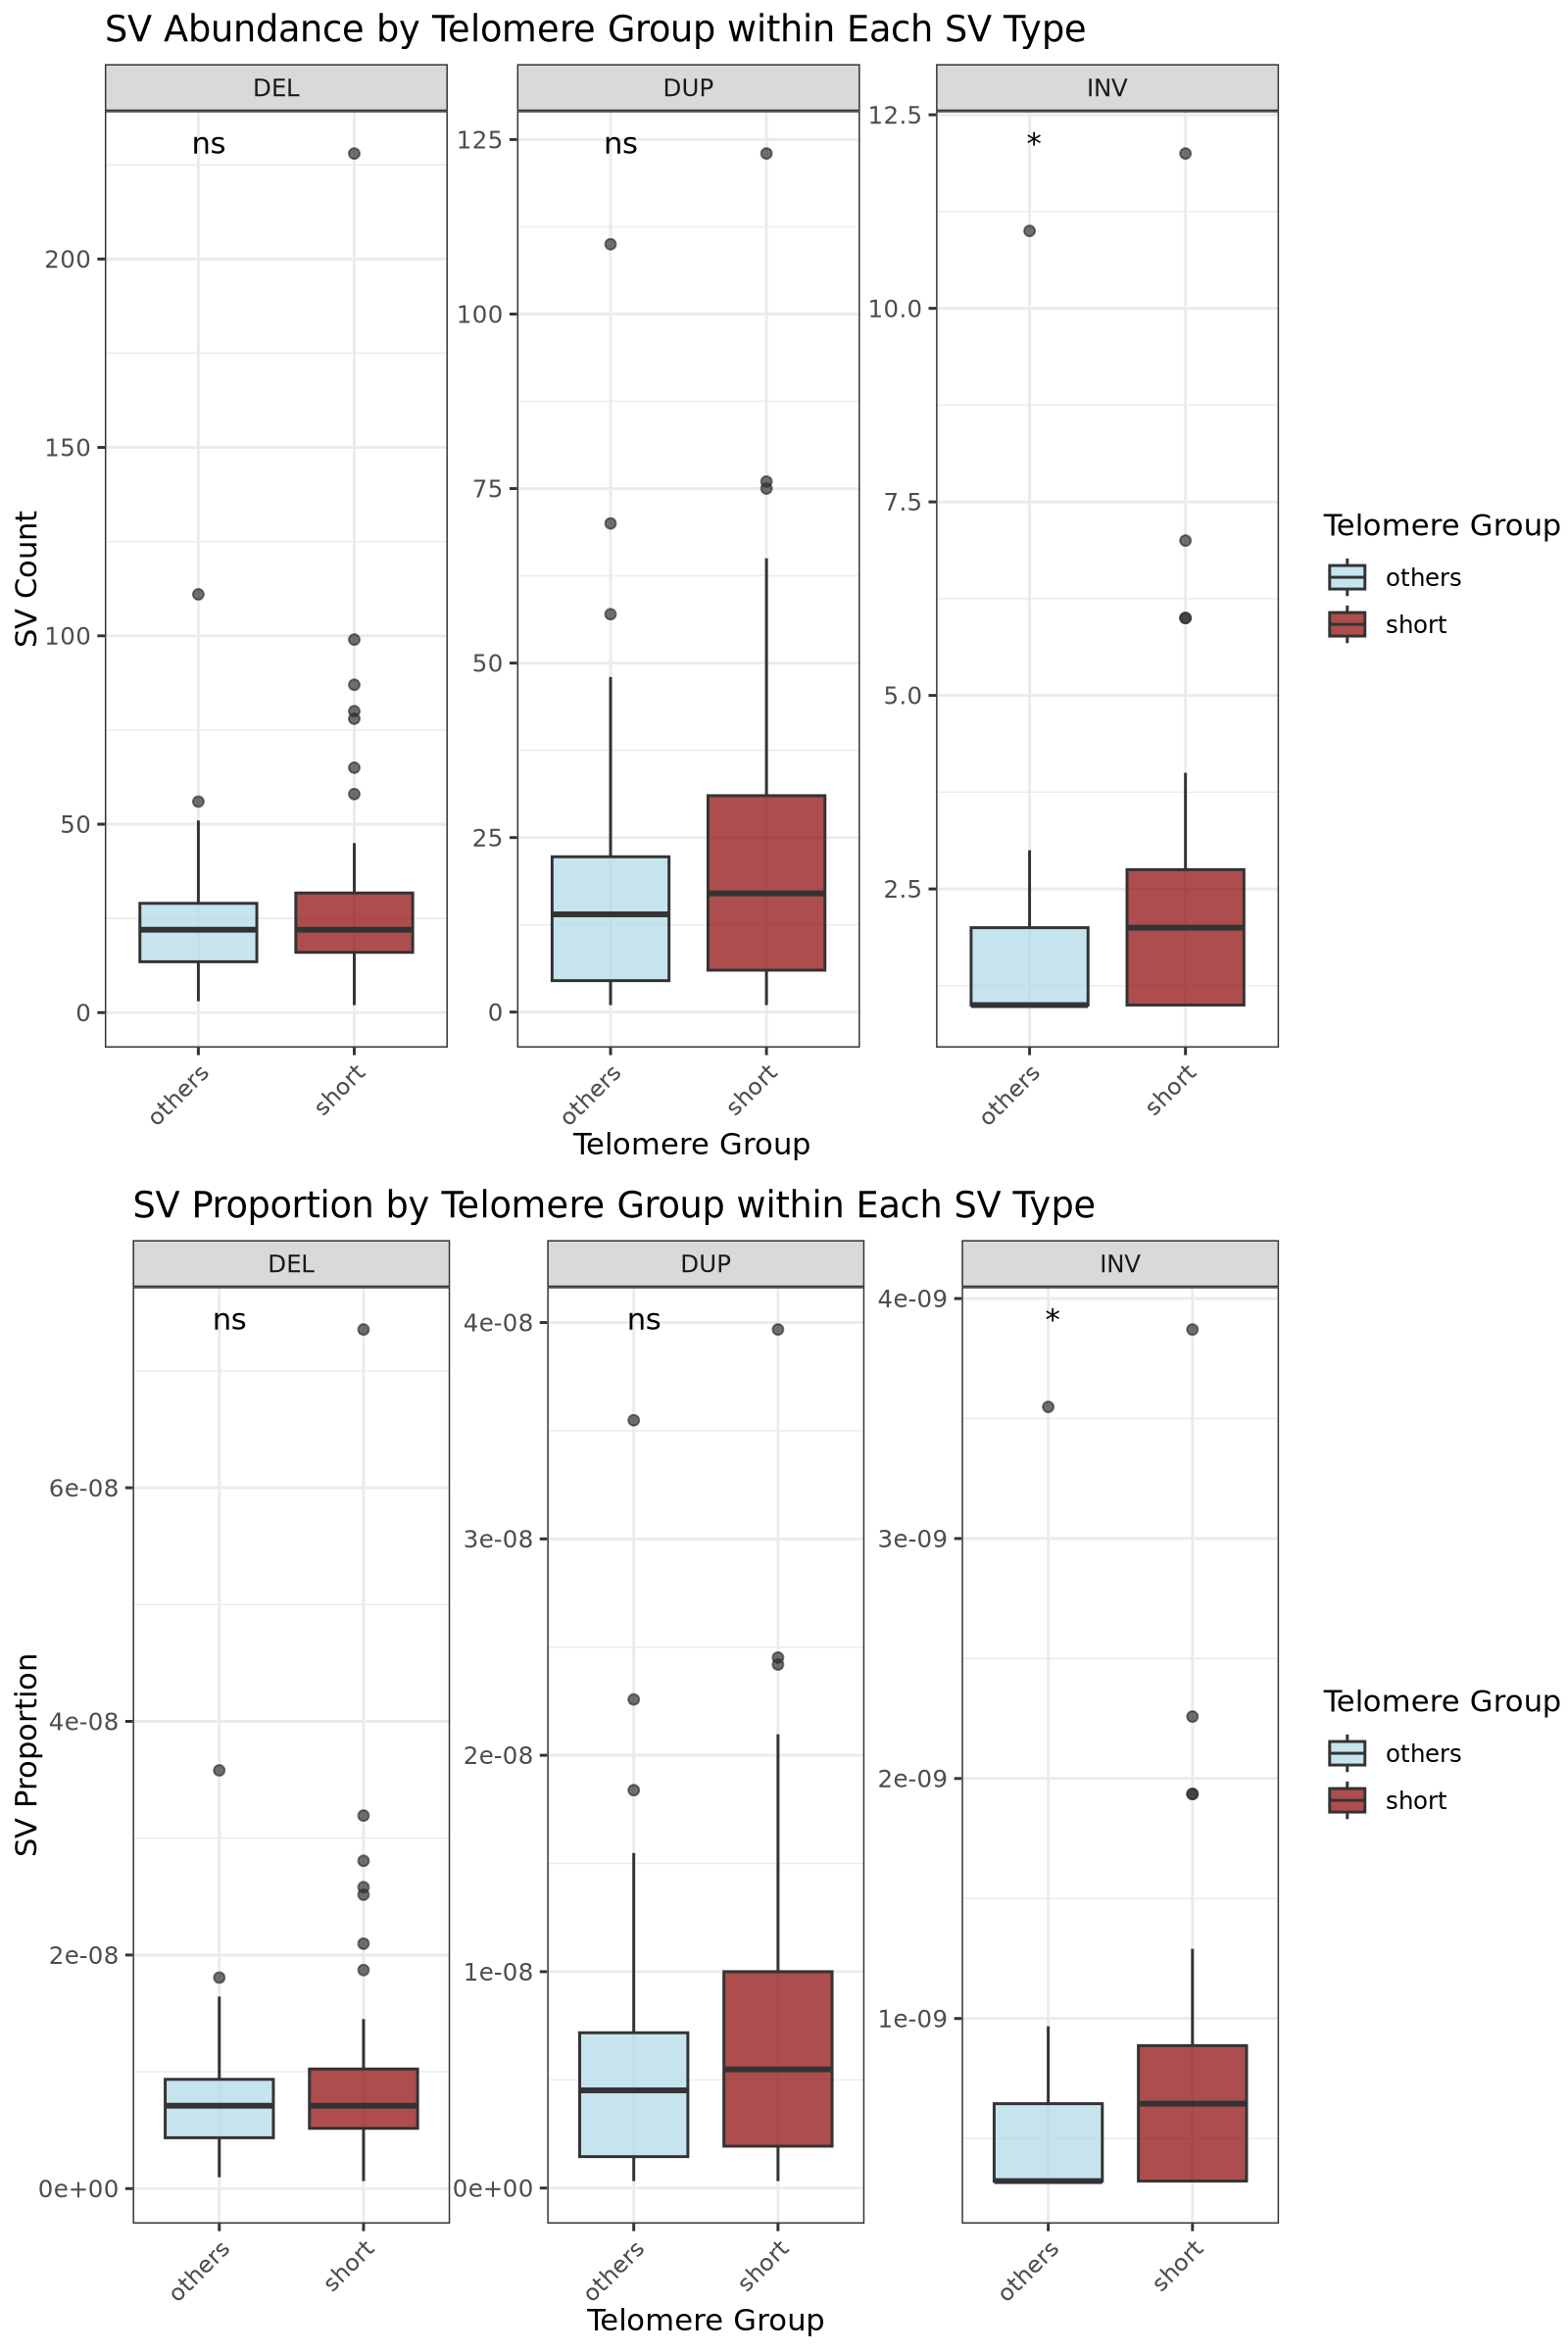

In [95]:
library(dplyr)
library(ggplot2)
library(ggpubr)

# Step 1: Ensure tel_group column exists
sv_tel_summary <- sv_tel_summary %>%
  mutate(tel_group = ifelse(telomere_diff > 0, "short", "others"))

# Step 2: Create plotting function with color customization
plot_metric_across_tel_group <- function(data, metric, y_label, title_prefix) {
  # Summarize metric per patient, SV type, and tel_group
  summary_df <- data %>%
    group_by(patient_id, SV_type.x, tel_group) %>%
    summarise(metric_value = sum(.data[[metric]], na.rm = TRUE), .groups = "drop")
    
  options(repr.plot.width = 8, repr.plot.height = 12, repr.plot.res = 200)

  # Boxplot comparing short vs others within each SV type
  p <- ggplot(summary_df, aes(x = tel_group, y = metric_value, fill = tel_group)) +
    geom_boxplot(alpha = 0.7) +
    stat_compare_means(method = "wilcox.test", label = "p.signif") +
    facet_wrap(~ SV_type.x, scales = "free_y") +
    labs(
      title = paste(title_prefix, "by Telomere Group within Each SV Type"),
      x = "Telomere Group",
      y = y_label,
      fill = "Telomere Group"
    ) +
    scale_fill_manual(values = c("short" = "darkred", "others" = "lightblue")) +
    theme_bw() +
    theme(axis.text.x = element_text(angle = 45, hjust = 1))
  
  return(p)
}

# Step 3: Create plots
p_count      <- plot_metric_across_tel_group(sv_tel_summary, "SV_count", "SV Count", "SV Abundance")
p_proportion <- plot_metric_across_tel_group(sv_tel_summary, "SV_proportion", "SV Proportion", "SV Proportion")

# Step 4: Arrange plots vertically
ggarrange(p_count, p_proportion, ncol = 1, nrow = 2)


In [96]:
# Save arranged plots to a PDF
ggsave(
  filename = "/scratch/mjehangir/manuscript_figures/TCGA_SV_telomere_group_comparison.pdf",
  plot = ggarrange(p_count, p_proportion, ncol = 1, nrow = 2),
  width = 8,
  height = 8,
  dpi = 300
)


In [ ]:
library(dplyr)
library(ggplot2)
library(ggpubr)

# Step 1: Ensure `tel_group` is defined
sv_tel_summary <- sv_tel_summary %>%
  mutate(tel_group = ifelse(telomere_diff > 0, "short", "long"))

# Step 2: Define function to plot metric comparisons across SV_type.x and category
plot_metric_by_svtype_and_category <- function(data, metric, y_label, title_prefix) {
  summary_df <- data %>%
    group_by(patient_id, SV_type.x, tel_group, category) %>%
    summarise(metric_value = sum(.data[[metric]], na.rm = TRUE), .groups = "drop")

    options(repr.plot.width = 8, repr.plot.height = 20, repr.plot.res = 200)

  p <- ggplot(summary_df, aes(x = tel_group, y = metric_value, fill = tel_group)) +
    geom_boxplot(alpha = 0.7, outlier.shape = NA) +
    stat_compare_means(method = "wilcox.test", label = "p.signif") +
    facet_grid(SV_type.x ~ category, scales = "free_y") +
    labs(
      title = paste(title_prefix, "by Telomere Group, SV Type, and Category"),
      x = "Telomere Group",
      y = y_label,
      fill = "Telomere Group"
    ) +
    theme_minimal(base_size = 12) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1))
  
  return(p)
}

# Step 3: Generate plots
p_count      <- plot_metric_by_svtype_and_category(sv_tel_summary, "SV_count", "SV Count", "SV Count")
p_density    <- plot_metric_by_svtype_and_category(sv_tel_summary, "SV_density", "SV Density", "SV Density")
p_proportion <- plot_metric_by_svtype_and_category(sv_tel_summary, "SV_proportion", "SV Proportion", "SV Proportion")

# Step 4: Arrange all plots vertically
ggarrange(p_count, p_density, p_proportion, ncol = 1, labels = c("A", "B", "C"))


In [ ]:
############## ALL TCGA SAMPLES ANALSYSIS##############################

In [ ]:
library(dplyr)
library(ggplot2)

# Filter for DEL and DUP only
sv_filtered <- sv_sample_subset %>%
  filter(SV_type.x %in% c("DEL", "DUP"))
sv_filtered <- sv_sample_subset %>%
  filter(SV_type.x %in% c("DEL", "DUP"), disease != "UVM")
         
# Prepare chromosome order for plotting
chromosome_levels <- paste0("chr", c(1:22, "X", "Y"))
sv_filtered$seqnames.x <- factor(sv_filtered$seqnames.x, levels = chromosome_levels)

# Convert positions to Mb for better scale
sv_filtered <- sv_filtered %>%
  mutate(midpoint = (start.x + end.x) / 2 / 1e6)



In [ ]:
library(dplyr)
library(ggplot2)

# Filter DEL and DUP only
sv_filtered <- sv_sample_subset %>%
  filter(SV_type.x %in% c("DEL", "DUP", "INV"))

# Prepare chromosome order
chromosome_levels <- paste0("chr", c(1:22, "X", "Y"))
sv_filtered$seqnames.x <- factor(sv_filtered$seqnames.x, levels = chromosome_levels)

# Create 1 Mb bins and count SVs per bin per disease, chromosome, and SV type
binned_sv <- sv_filtered %>%
  mutate(bin = floor((start.x + end.x) / 2 / 1e6)) %>%  # midpoint in Mb
  group_by(disease, seqnames.x, SV_type.x, bin) %>%
  summarise(SV_count = n(), .groups = "drop") %>%
  mutate(bin_midpoint = bin + 0.5)  # for plotting midpoint of bin

options(repr.plot.width = 30, repr.plot.height = 30, repr.plot.res = 200)

  ggplot(binned_sv, aes(x = bin_midpoint, y = SV_count, color = SV_type.x)) +
  geom_line() +
  facet_grid(disease ~ seqnames.x, scales = "free_y", space = "free_x") +  # free_y here!
  scale_color_manual(values = c(DEL = "blue", DUP = "red", INV = "orange")) +
  labs(
    title = "SV counts per 1Mb bin by SV Type across Chromosomes and Cancer Types",
    x = "Position on Chromosome (Mb)",
    y = "SV Count",
    color = "SV Type"
  ) +
  theme_minimal() +
  theme(
    legend.position = "bottom",
    axis.text.x = element_text(angle = 90, size = 6),
    strip.text.x = element_text(size = 8),
    strip.text.y = element_text(size = 8)
  )



In [ ]:
head(sv_filtered)

In [ ]:
library(tidyverse)
library(BSgenome.Hsapiens.UCSC.hg38)
Hsapiens <- BSgenome.Hsapiens.UCSC.hg38

# Load cytoband data
cyto_url <- "http://hgdownload.cse.ucsc.edu/goldenPath/hg38/database/cytoBand.txt.gz"
cyto <- read_tsv(cyto_url, col_names = c("seqnames", "start", "end", "band", "stain"), show_col_types = FALSE)

# Define centromeres
centromeres <- cyto %>%
  filter(stain == "acen") %>%
  group_by(seqnames) %>%
  summarize(cen_start = min(start), cen_end = max(end), .groups = "drop")

# Telomere coordinates (1Mb from each end)
chrom_lengths <- seqlengths(Hsapiens)[paste0("chr", 1:22)]
tel_len <- 1e6
telomeres <- tibble(
  seqnames = names(chrom_lengths),
  chr_len = as.numeric(chrom_lengths)
) %>%
  mutate(
    tel_p_start = 0,
    tel_p_end = pmin(tel_len, chr_len),
    tel_q_start = pmax(0, chr_len - tel_len),
    tel_q_end = chr_len
  )

# Prepare your SV data
sv_scaled <- sv_filtered %>%
  filter(SV_type.x %in% c("DEL", "DUP", "INV", "INS")) %>%
  mutate(midpoint = (start.x + end.x) / 2) %>%
  left_join(
    tibble(seqnames = names(chrom_lengths), chr_length = as.numeric(chrom_lengths)),
    by = c("seqnames.x" = "seqnames")
  ) %>%
  mutate(
    scaled_pos = midpoint / chr_length,
    cancer_type = disease  # use your existing 'disease' column
  ) %>%
  filter(!is.na(scaled_pos), seqnames.x %in% paste0("chr", 1:22))

# Shaded region prep
shade_cent <- centromeres %>%
  left_join(
    tibble(seqnames = names(chrom_lengths), chr_length = as.numeric(chrom_lengths)),
    by = "seqnames"
  ) %>%
  transmute(seqnames, type = "centromere", xmin = cen_start / chr_length, xmax = cen_end / chr_length)

shade_tel_p <- telomeres %>%
  transmute(seqnames, type = "tel_p", xmin = tel_p_start / chr_len, xmax = tel_p_end / chr_len)

shade_tel_q <- telomeres %>%
  transmute(seqnames, type = "tel_q", xmin = tel_q_start / chr_len, xmax = tel_q_end / chr_len)

shade_regions <- bind_rows(shade_cent, shade_tel_p, shade_tel_q)

# Final plot: One panel per cancer type
ggplot(sv_scaled, aes(x = scaled_pos, color = SV_type.x)) +
  geom_rect(
    data = shade_regions,
    aes(xmin = xmin, xmax = xmax, ymin = -Inf, ymax = Inf, fill = type),
    inherit.aes = FALSE,
    alpha = 0.15
  ) +
  geom_density(adjust = 1, size = 1.1, fill = NA) +
  facet_wrap(~ cancer_type, scales = "free_y", ncol = 3) +
  scale_color_manual(
    values = c(DEL = "blue", DUP = "red", INS = "green4", INV = "orange"),
    name = "SV Type"
  ) +
  scale_fill_manual(
    values = c(centromere = "khaki", tel_p = "lightblue", tel_q = "lightpink"),
    guide = guide_legend(override.aes = list(alpha = 0.3)),
    name = "Region"
  ) +
  labs(
    x = "Normalized Chromosome Position",
    y = "SV Density",
    title = "SV Distribution per Cancer Type (Scaled Positions)"
  ) +
  theme_bw(base_size = 12) +
  theme(
    plot.title = element_text(hjust = 0.5),
    legend.box = "vertical",
    legend.position = "bottom"
  )
